In [20]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

In [21]:
output_data_paths = ['/home/miguel/GI/2 - Reconstruction/scripts/output/output_data.json']

In [22]:
# Load the JSON data
all_output_data = []
for output_data_path in output_data_paths:
    if os.path.exists(output_data_path):
        with open(output_data_path, 'r') as file:
            output_data = json.load(file)
            print(len(output_data))
            for model_data in output_data:
                all_output_data.append(model_data)

20


In [23]:
output_data = all_output_data

In [24]:
model_shortnames = {
    'uwm-unet-train-set-size-288': "Improved UNet",
    'uwm-unet-singan-train-set-size-861': "SinGAN-augmented, n=861",
    'uwm-unet-singan-finetuning-train-set-size-861': "SinGAN-finetuned, n=861",
    'uwm-unet-singan-finetuned-n-10-10x-train-set-size-861': "SinGAN-FT-augmented, n=861"
}

In [25]:
cv_subjects = set([model_data['cv_subject'] for model_data in output_data])

In [26]:
model_data.keys()

dict_keys(['model', 'cv_subject', 'mask_path', '4d_reconstruction_path', 'matlab_output', 'cross_section_data', 'mid_slice_cross_sectional_area_uncentered'])

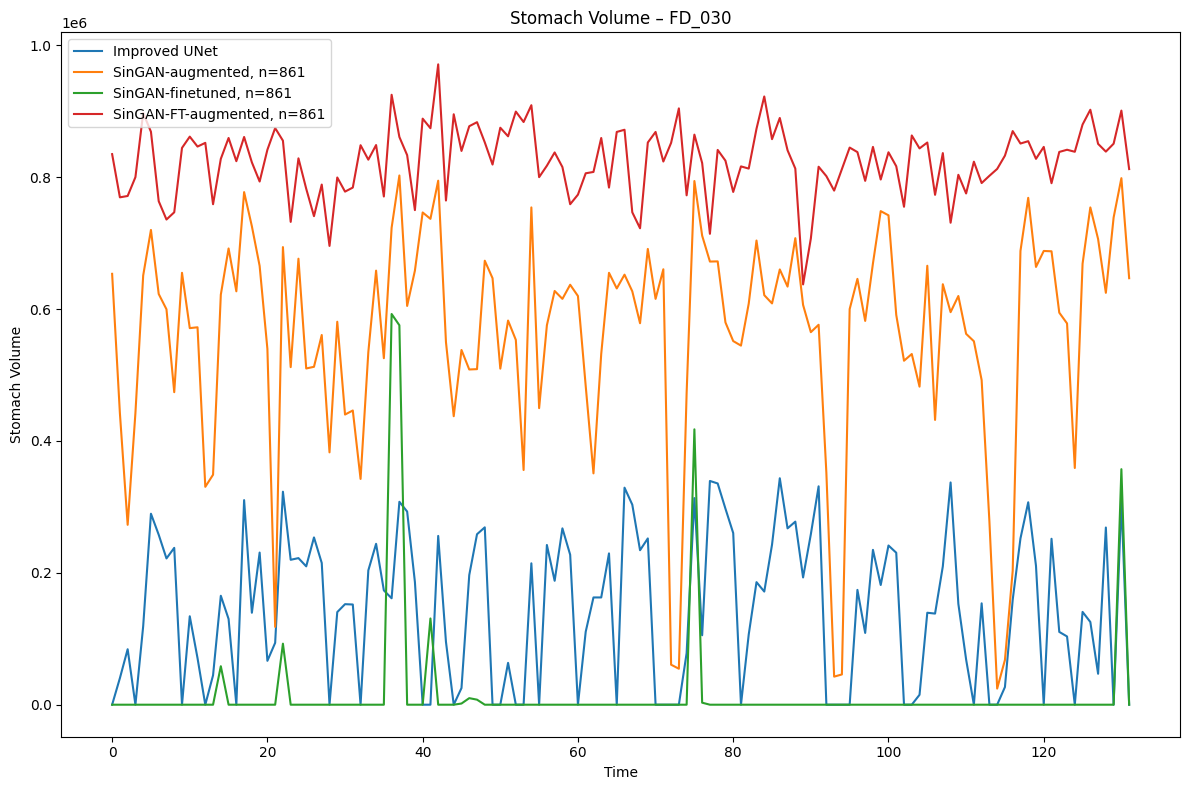

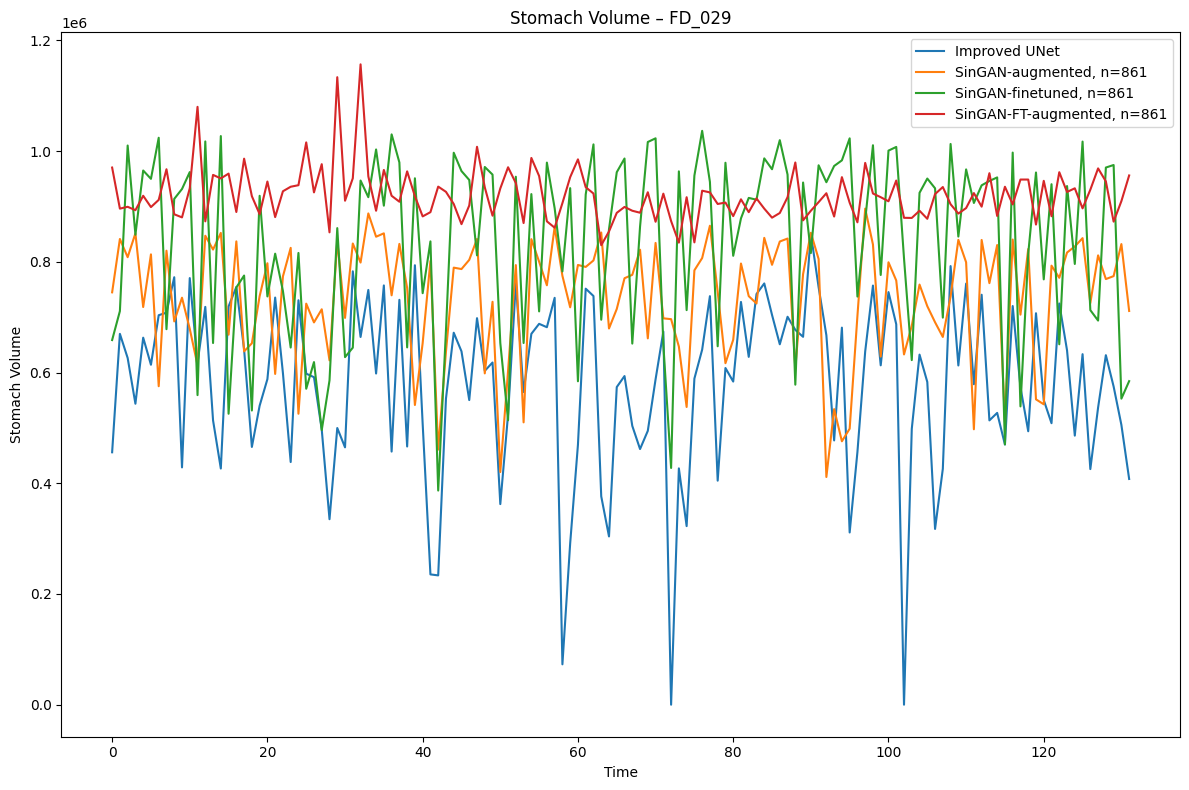

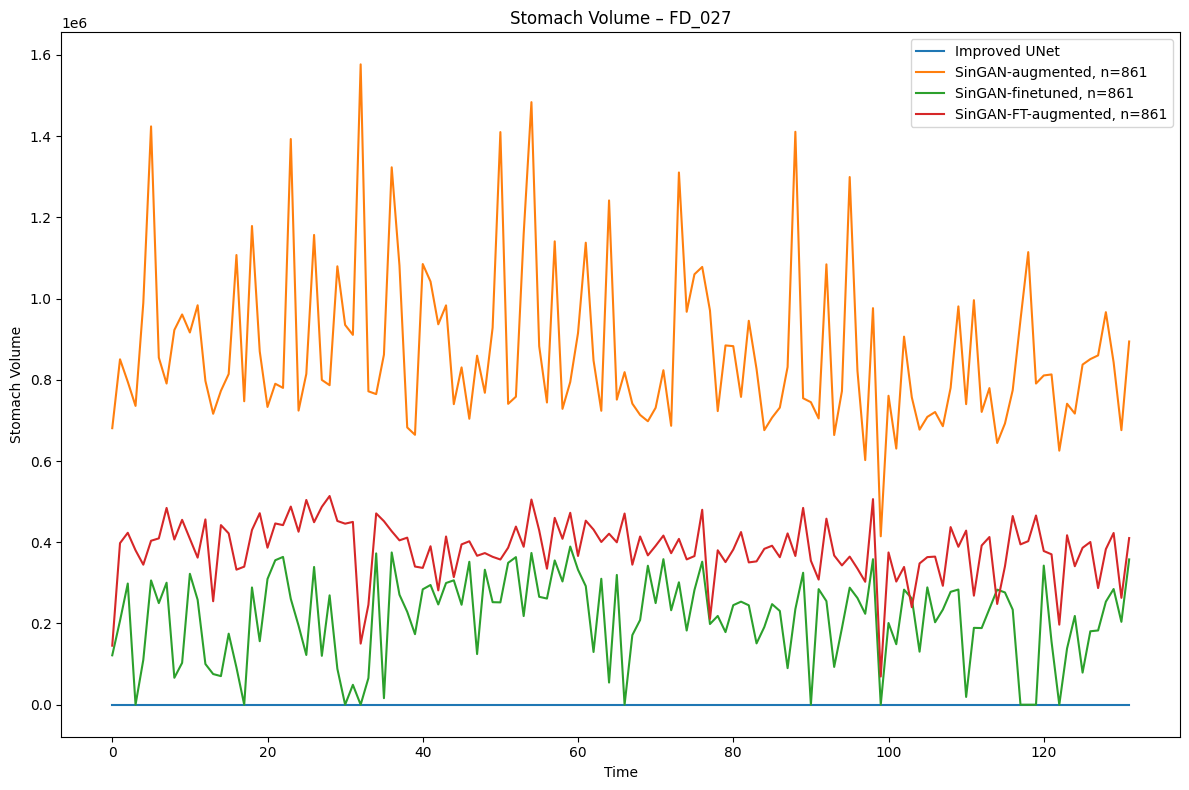

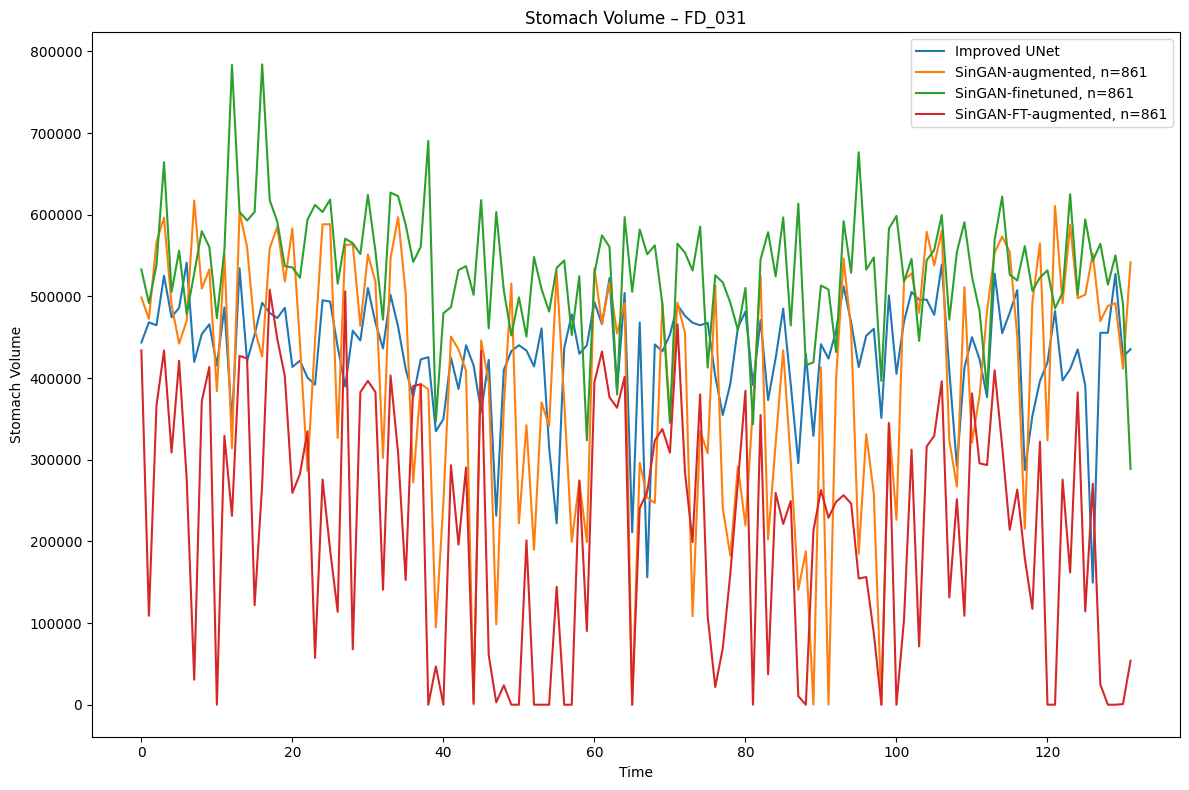

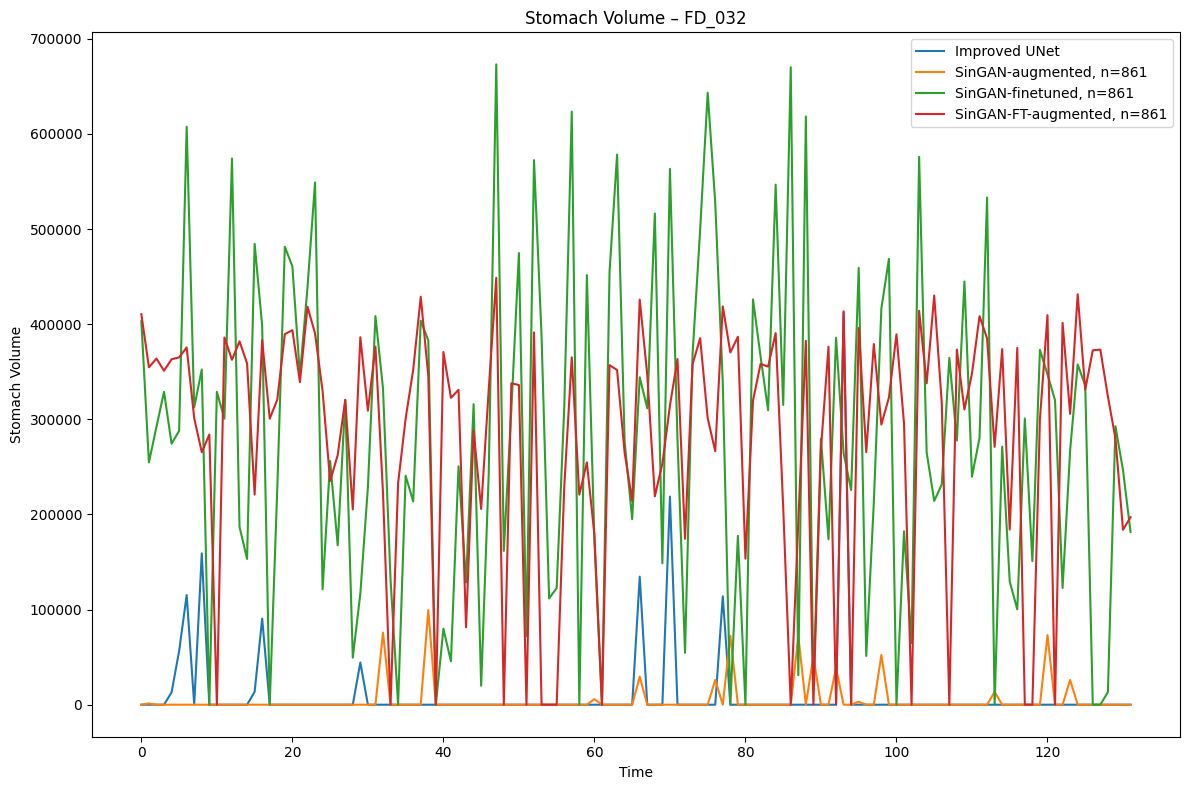

In [27]:
for cv_subject in cv_subjects:
    fig, ax = plt.subplots(figsize=(12, 8))
    for model_data in output_data:
        if model_data['cv_subject'] == cv_subject:
            ax.plot(
                model_data['mid_slice_cross_sectional_area_uncentered'],
                label=model_shortnames[model_data['model']]
            )
    ax.set(
        xlabel='Time',
        ylabel='Stomach Volume',
        title=f'Stomach Volume – {cv_subject}'
    )
    ax.legend()
    fig.tight_layout()
    plt.show()

In [28]:
len(output_data)

20

In [29]:
1

1

In [30]:
import re
def parse_matlab_output(text):
    # 1) stomachMask size: four ints on one line
    size_m = re.search(
        r"Size of stomachMask:\s*([\d]+\s+[\d]+\s+[\d]+\s+[\d]+)", 
        text
    )
    stomach_mask_size = tuple(map(int, size_m.group(1).split()))

    # 2) dominant frequency: one float
    dom_m = re.search(
        r"Dominant Frequency \(Hz\):\s*([0-9]*\.?[0-9]+)", 
        text
    )
    dominant_frequency_hz = float(dom_m.group(1))

    # 3) wave speeds block up until the Warning (or end of string)
    wave_m = re.search(
        r"Wave propagation speeds \(mm/s\):\s*(.*?)(?=Warning:|$)",
        text,
        re.DOTALL
    )
    wave_block = wave_m.group(1)

    # extract all floats, 'Inf', or 'NaN'
    raw_speeds = re.findall(r"-?\d*\.\d+|Inf|NaN", wave_block)

    # convert: Inf → +inf, NaN → 0.0, else float
    wave_propagation_speeds_mm_s = []
    for x in raw_speeds:
        if x == "Inf":
            wave_propagation_speeds_mm_s.append(float("inf"))
        elif x == "NaN":
            wave_propagation_speeds_mm_s.append(0.0)
        else:
            wave_propagation_speeds_mm_s.append(float(x))

    return stomach_mask_size, dominant_frequency_hz, wave_propagation_speeds_mm_s

In [31]:
results = {}
for md in output_data:
    subj = md['cv_subject']
    size, freq, speeds = parse_matlab_output(md['matlab_output'])
    entry = {
        'model': md['model'],
        'stomach_mask_size': size,
        'dominant_frequency_hz': freq,
        'wave_propagation_speeds_mm_s': speeds
    }
    results.setdefault(subj, []).append(entry)

In [32]:
import numpy as np

In [40]:
import pandas as pd

rows = []
for subj, entries in results.items():
    for entry in entries:
        rows.append({
            "Subject": subj,
            "Model": model_shortnames[entry['model']],
            "Dominant Frequency (Hz)": entry['dominant_frequency_hz']
        })

df = pd.DataFrame(rows)

# Pivot: subjects as rows, models as columns
pivot_df = df.pivot(index="Subject", columns="Model", values="Dominant Frequency (Hz)")

In [41]:
pivot_df

Model,Improved UNet,"SinGAN-FT-augmented, n=861","SinGAN-augmented, n=861","SinGAN-finetuned, n=861"
Subject,,,,
FD_027,0.0000,0.0606,0.0909,0.0530
FD_029,0.1364,0.0606,0.0909,0.0682
FD_030,0.0985,0.0985,0.0985,0.0530
FD_031,0.0985,0.0985,0.0985,0.0985
FD_032,0.1288,0.1894,0.1818,0.1970


Subject: FD_027


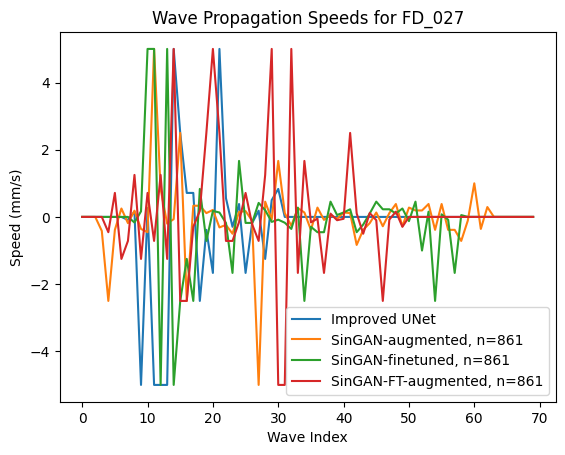

/tmp/ipykernel_2470025/568984630.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plt.imshow(t_test_p_values.fillna(1).values, vmin=-1, vmax=1, cmap='RdBu')


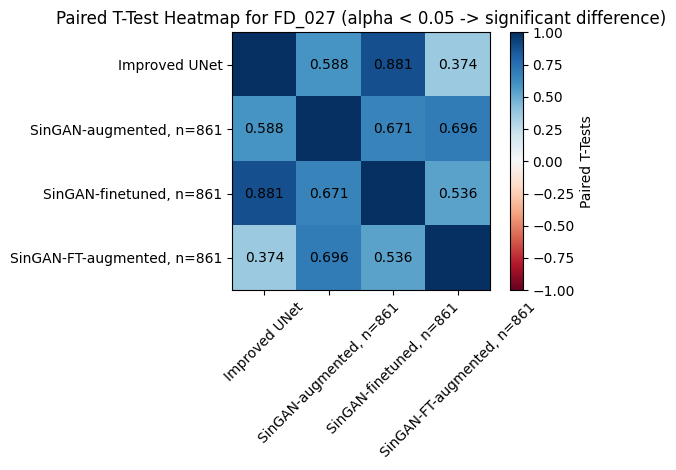

Pairs:
====


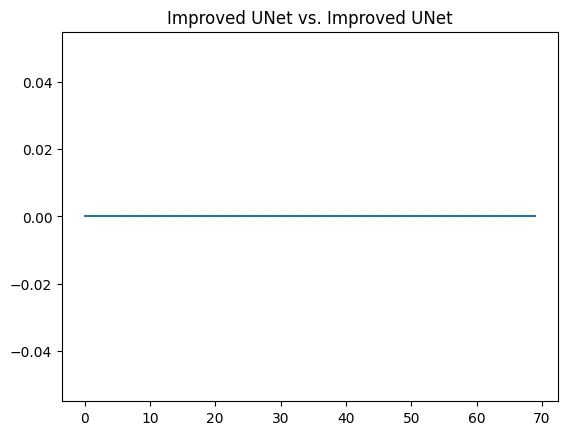

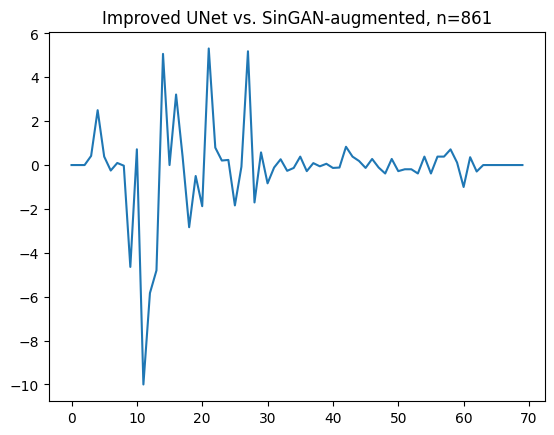

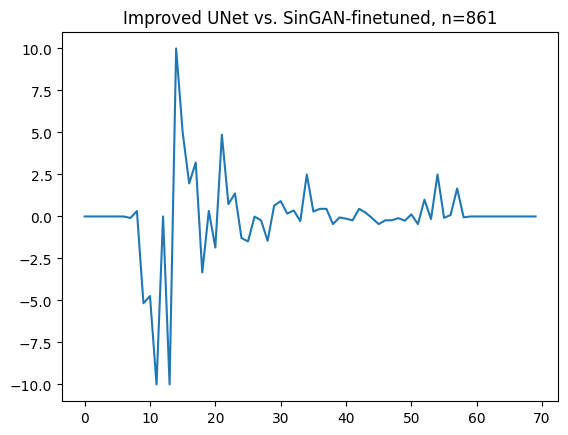

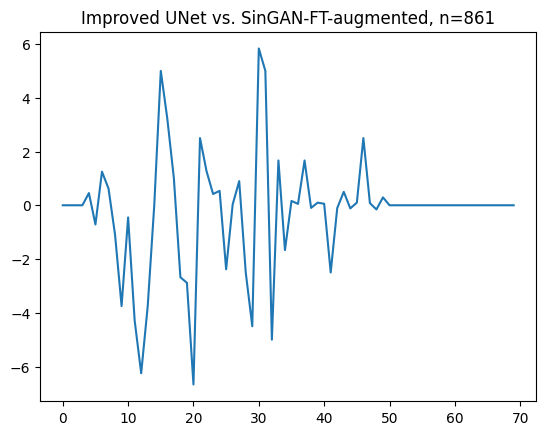

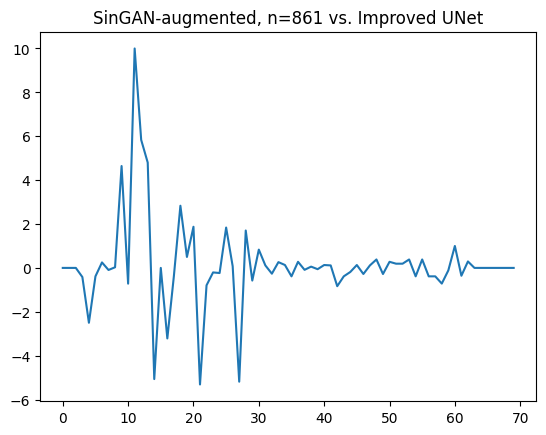

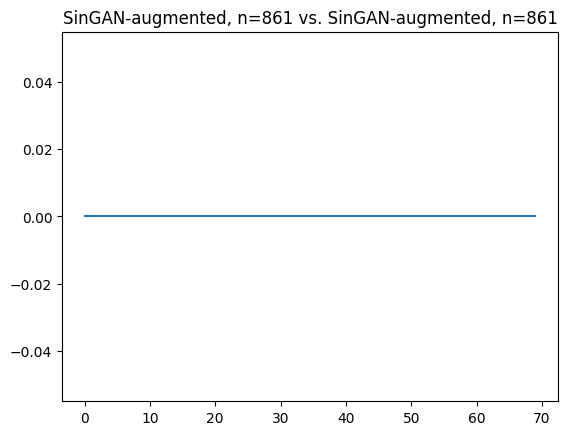

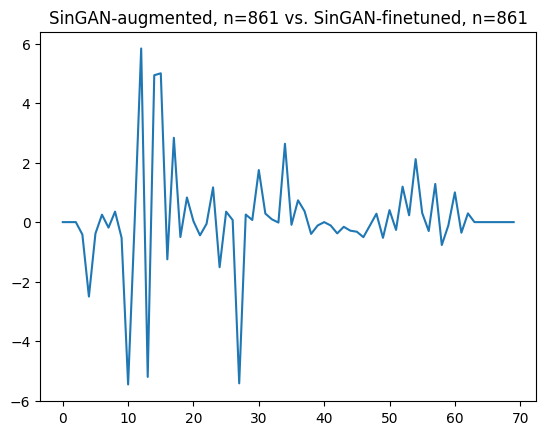

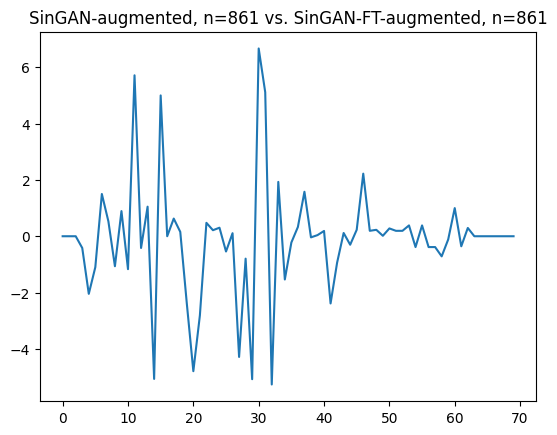

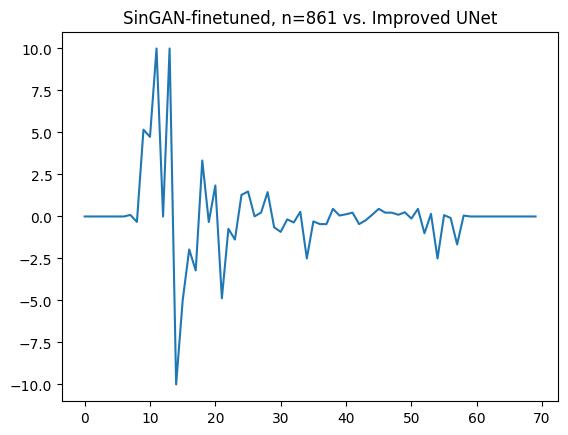

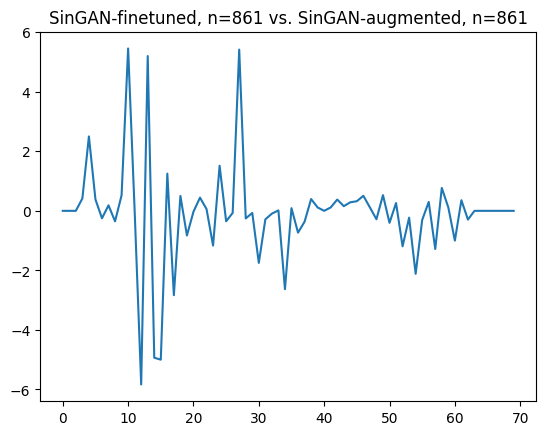

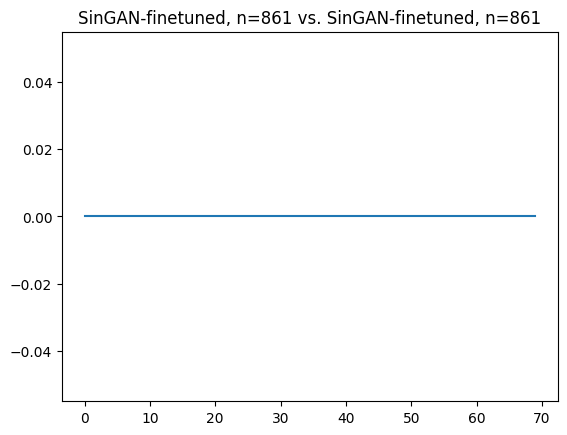

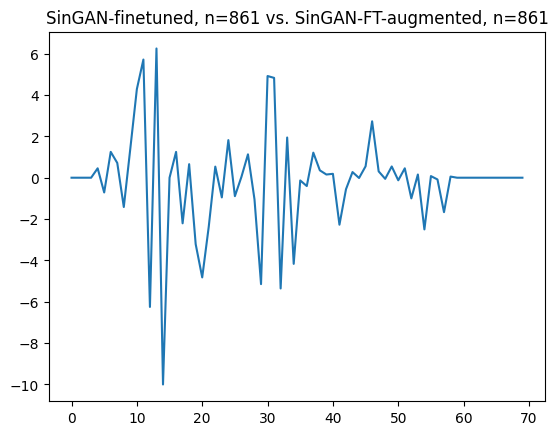

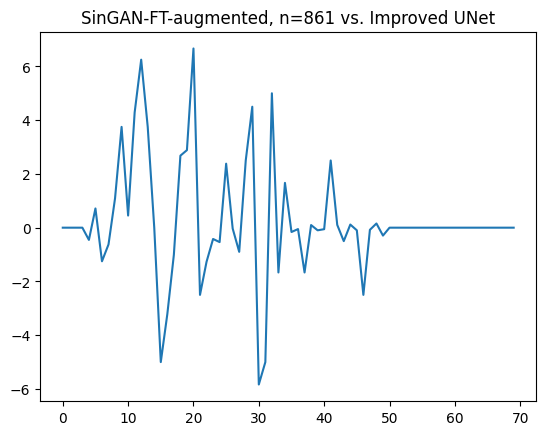

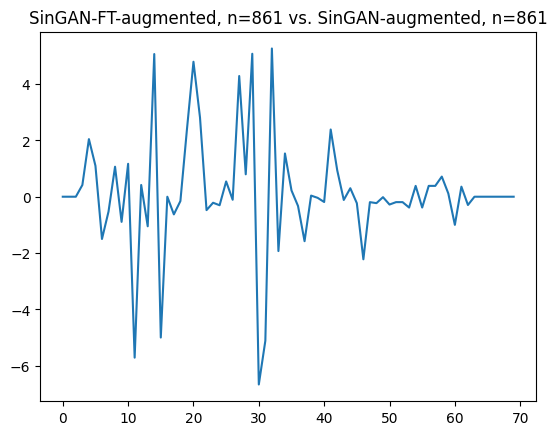

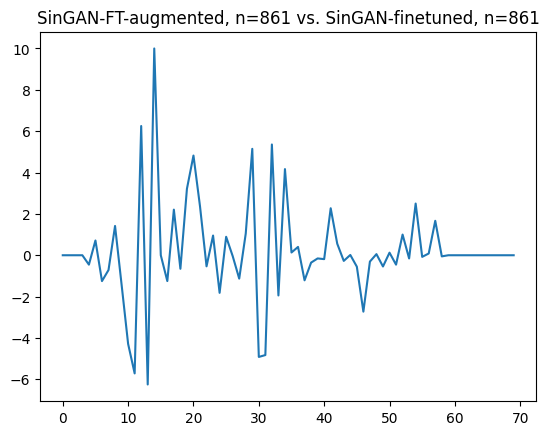

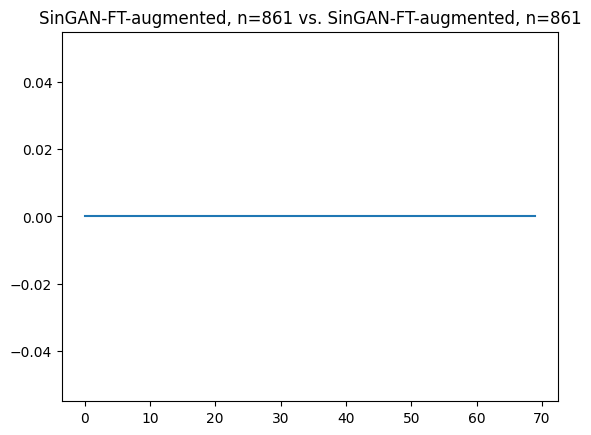

====
Subject: FD_029


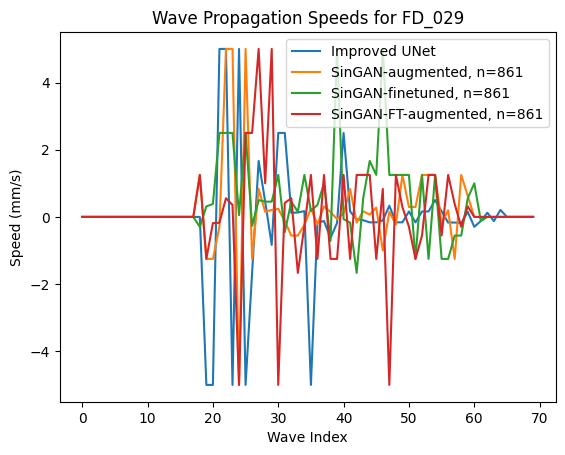

/tmp/ipykernel_2470025/568984630.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plt.imshow(t_test_p_values.fillna(1).values, vmin=-1, vmax=1, cmap='RdBu')


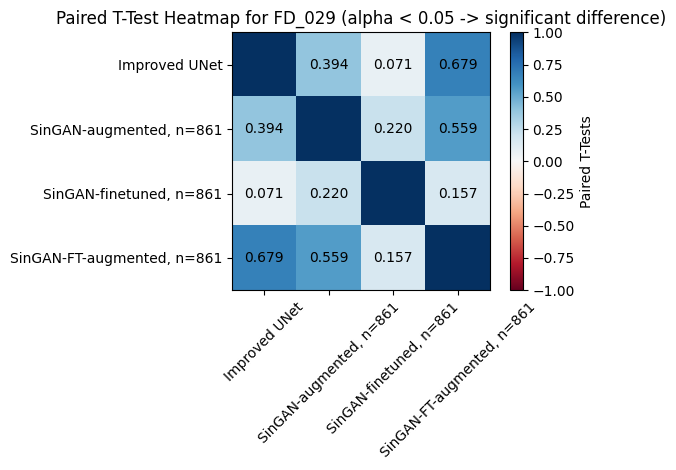

Pairs:
====


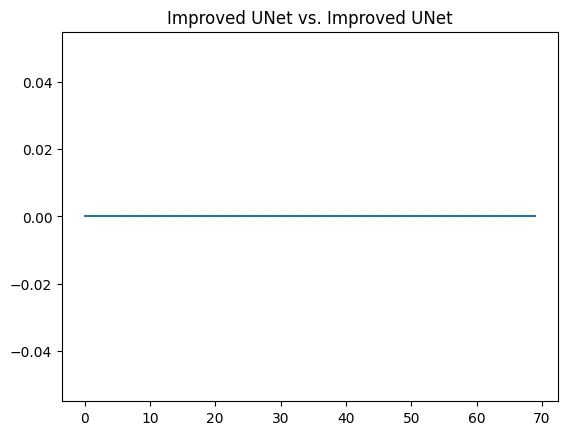

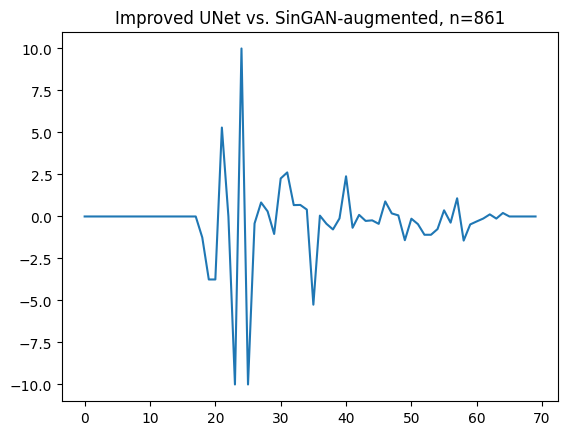

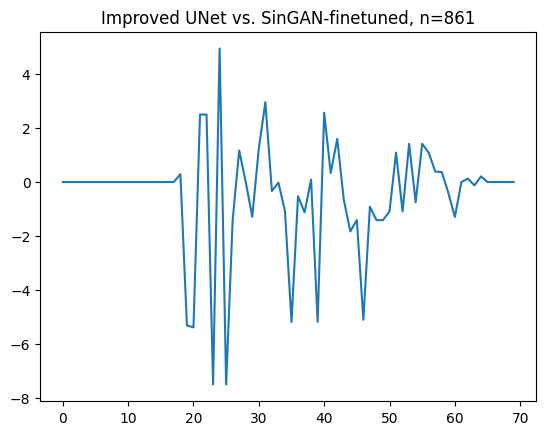

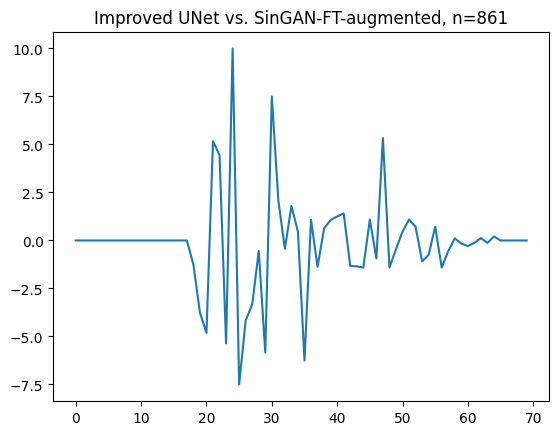

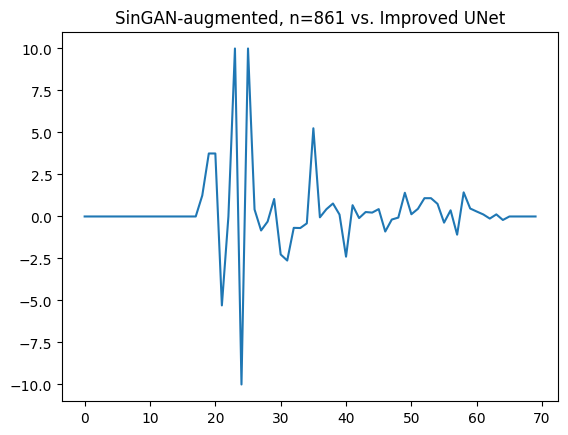

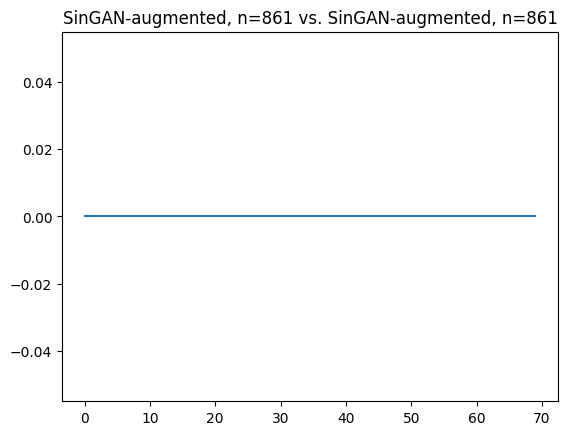

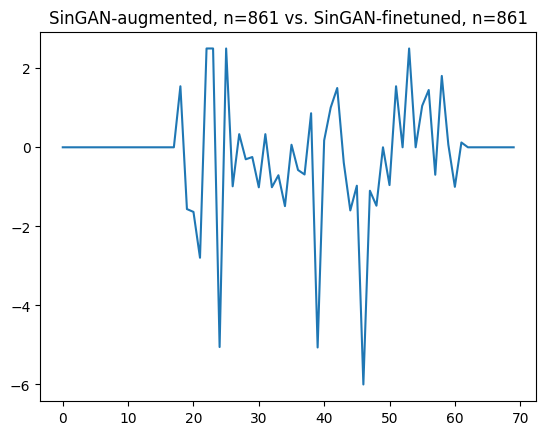

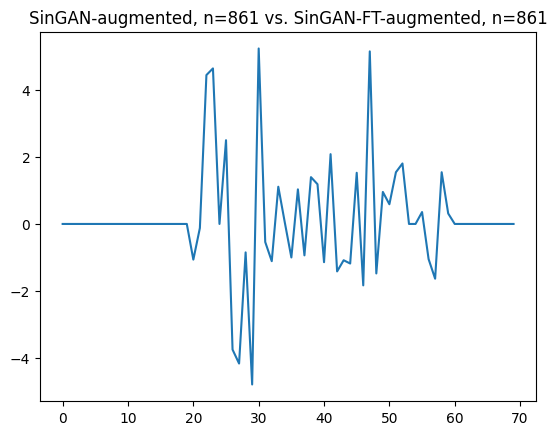

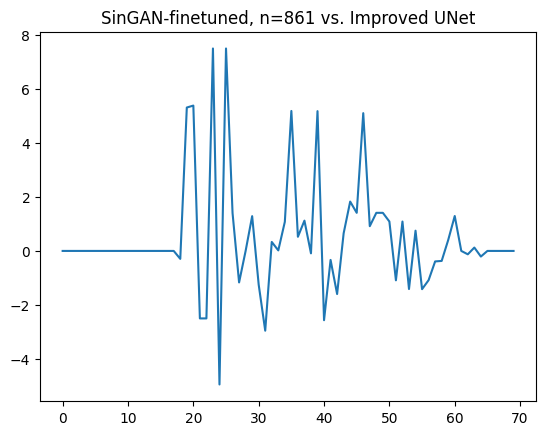

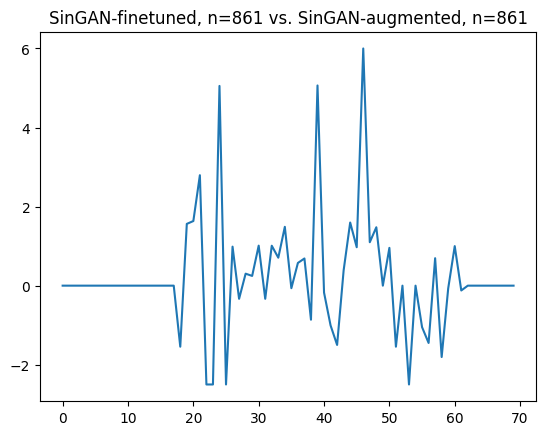

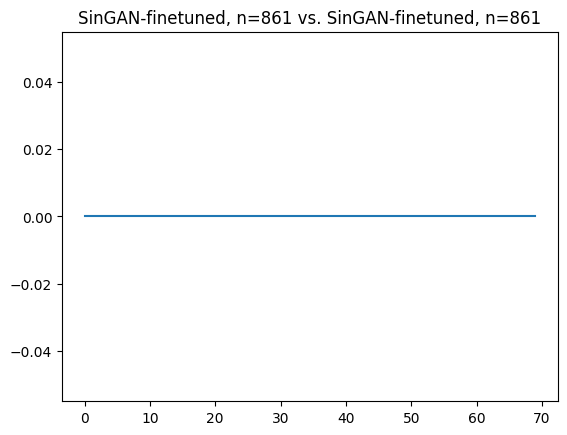

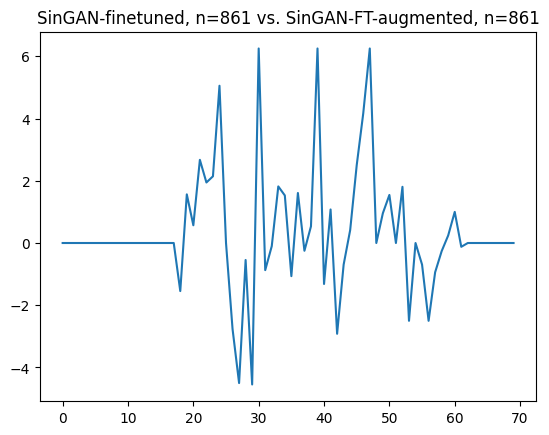

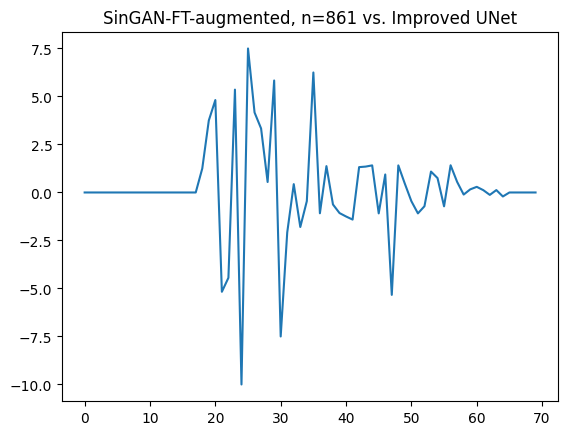

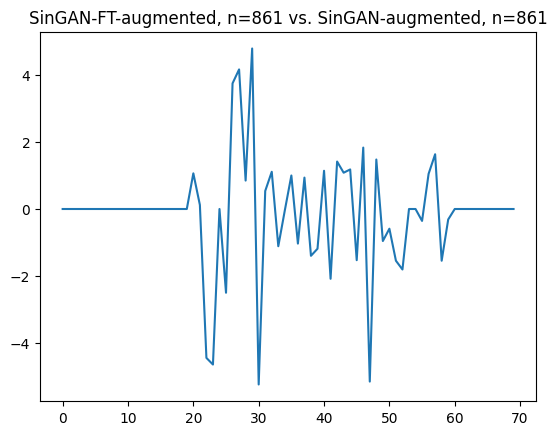

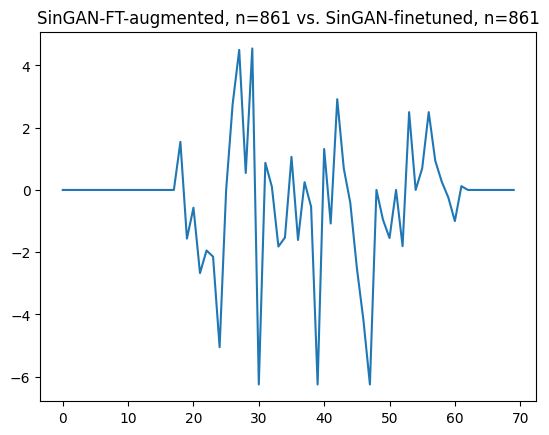

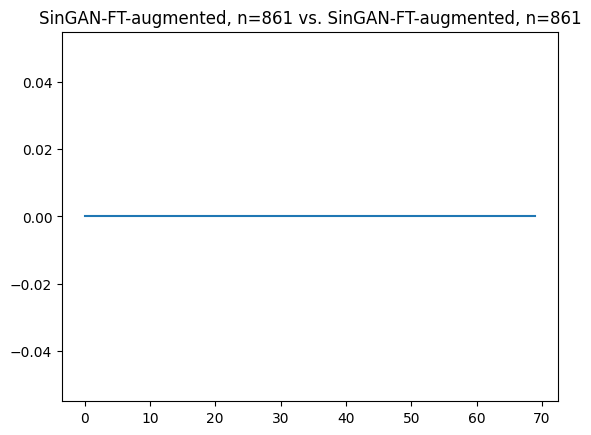

====
Subject: FD_030


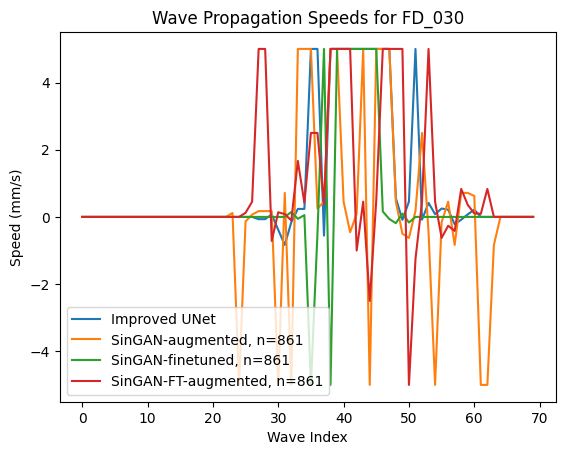

/tmp/ipykernel_2470025/568984630.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plt.imshow(t_test_p_values.fillna(1).values, vmin=-1, vmax=1, cmap='RdBu')


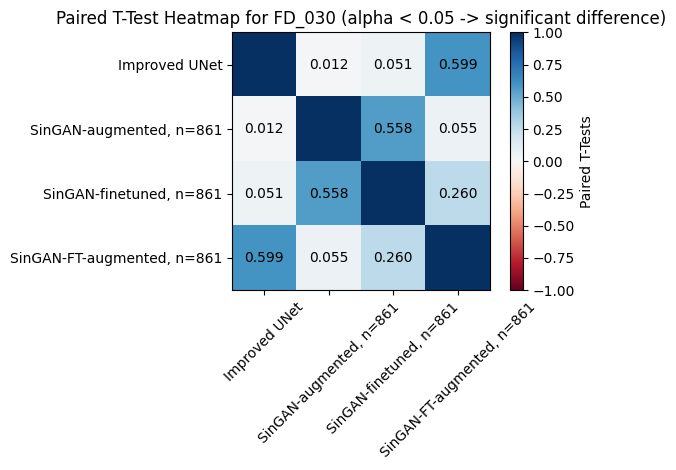

Pairs:
====


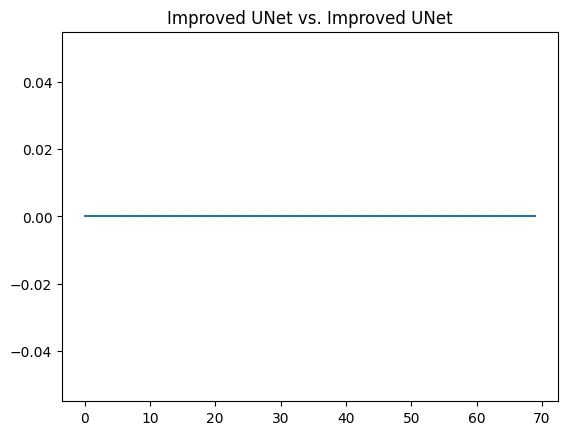

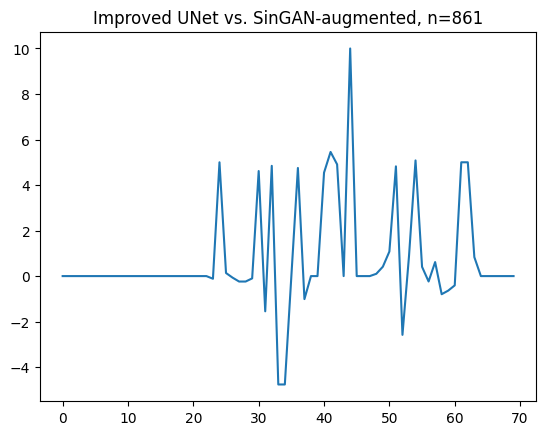

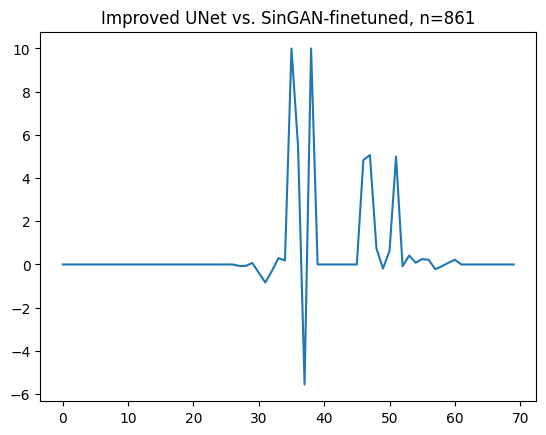

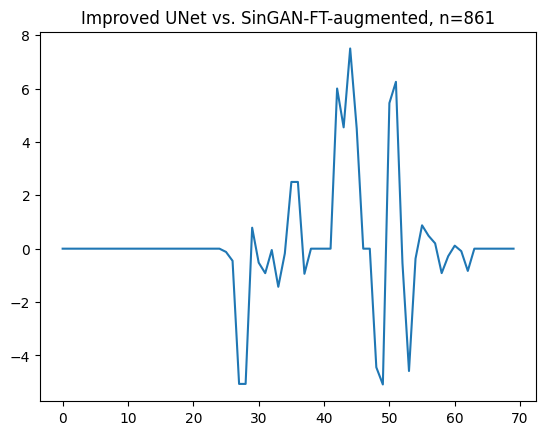

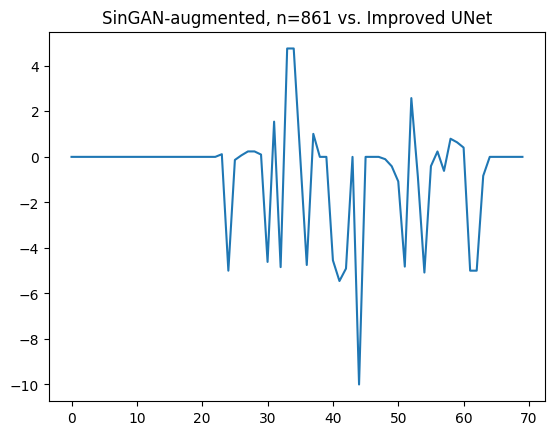

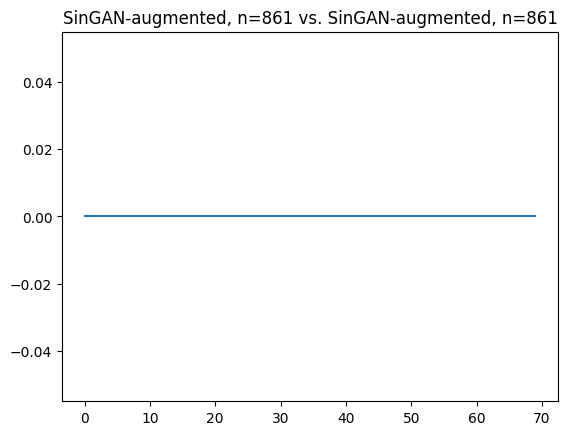

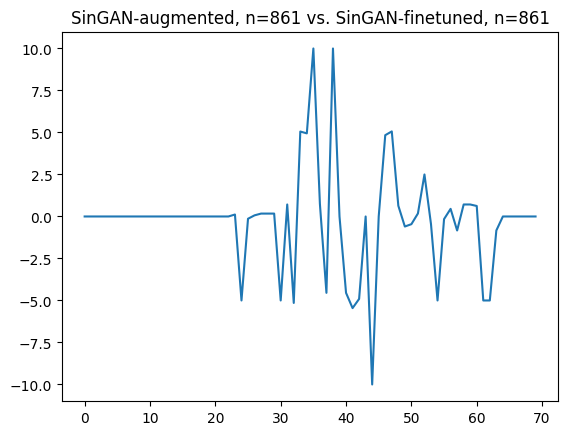

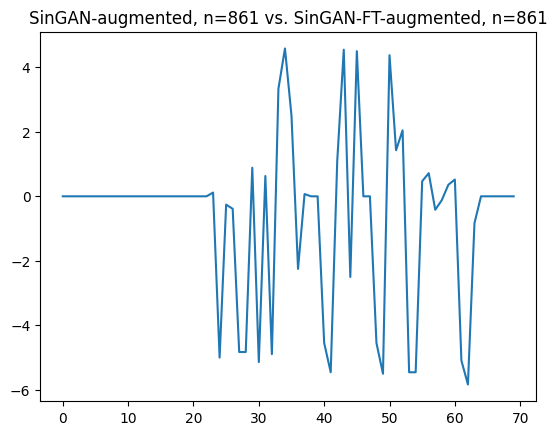

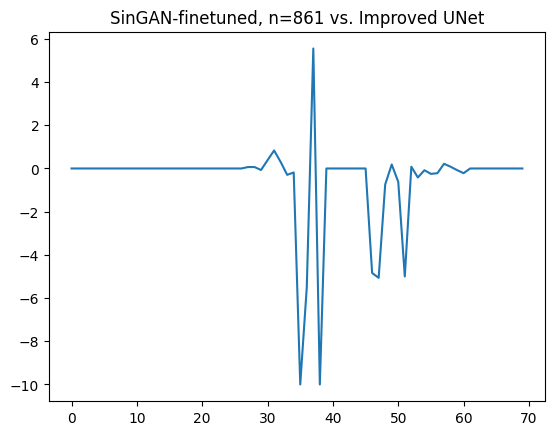

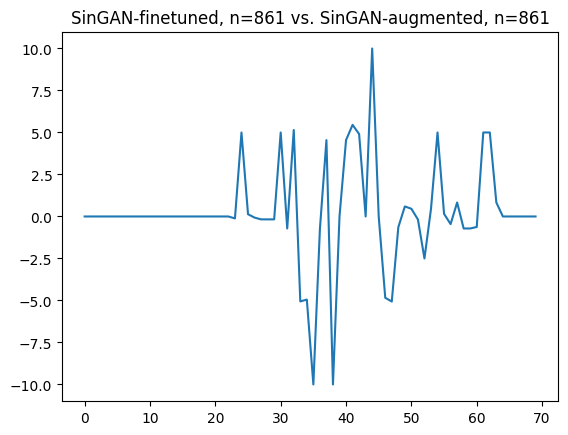

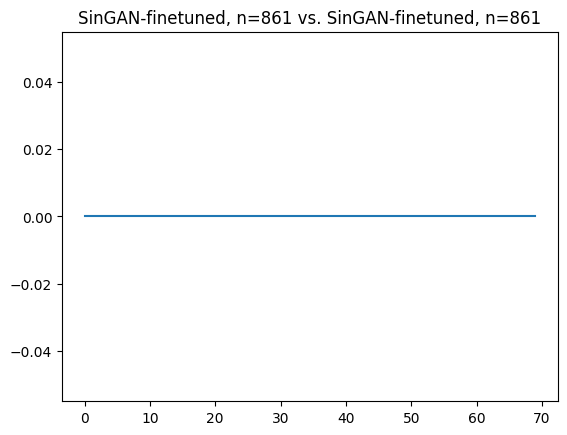

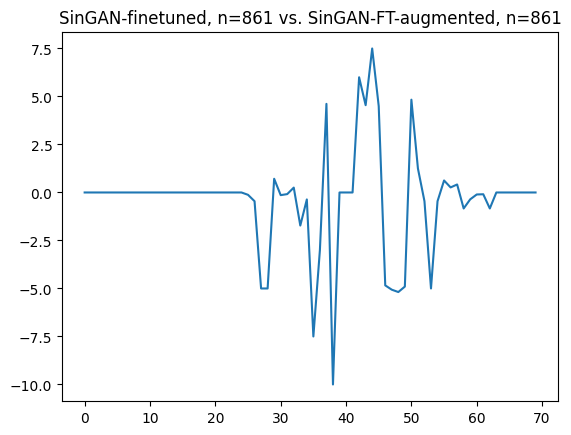

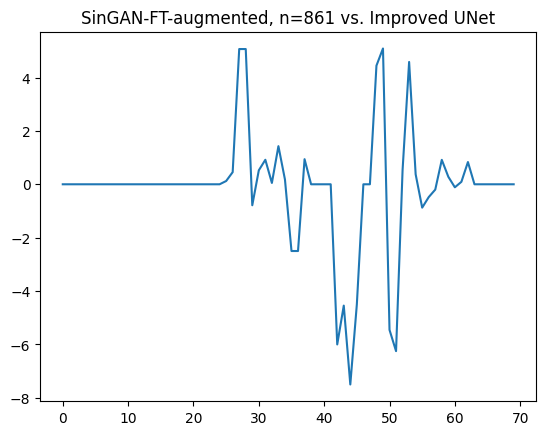

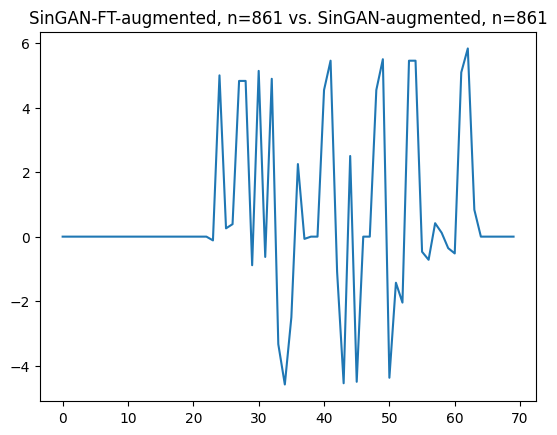

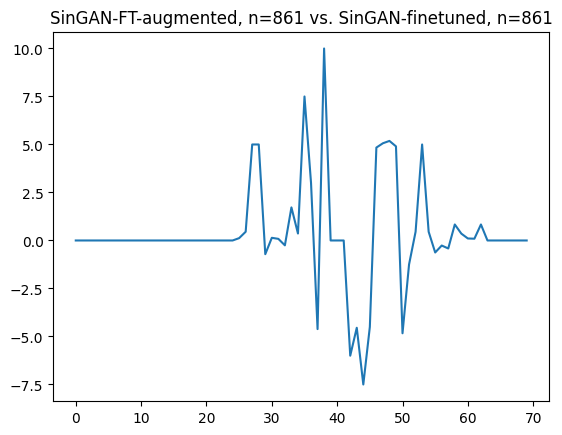

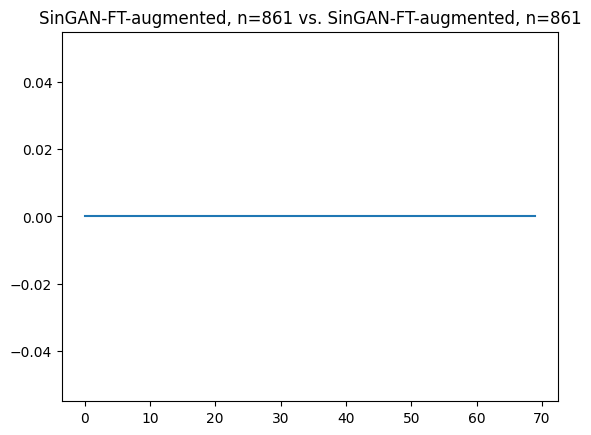

====
Subject: FD_031


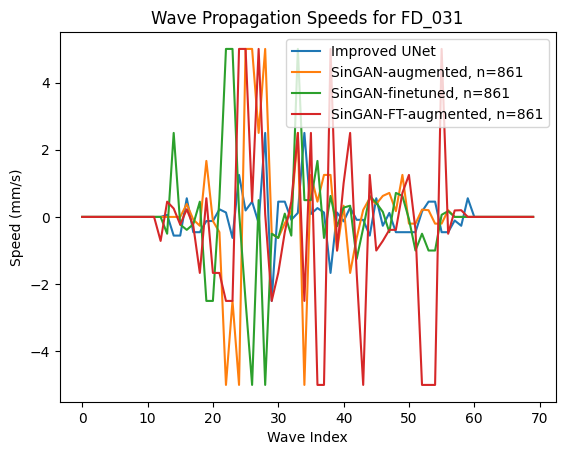

/tmp/ipykernel_2470025/568984630.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plt.imshow(t_test_p_values.fillna(1).values, vmin=-1, vmax=1, cmap='RdBu')


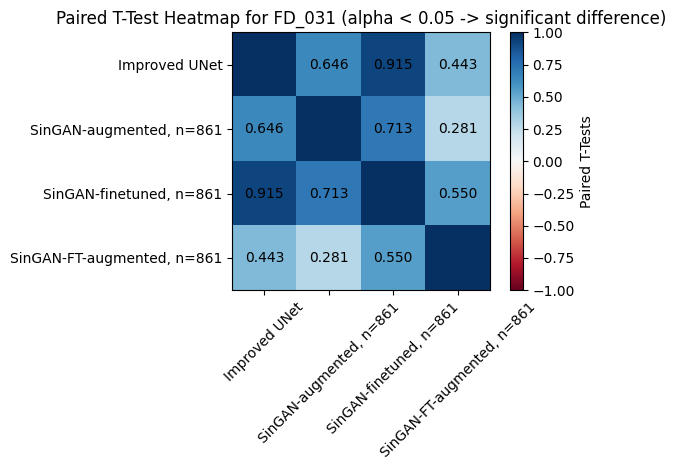

Pairs:
====


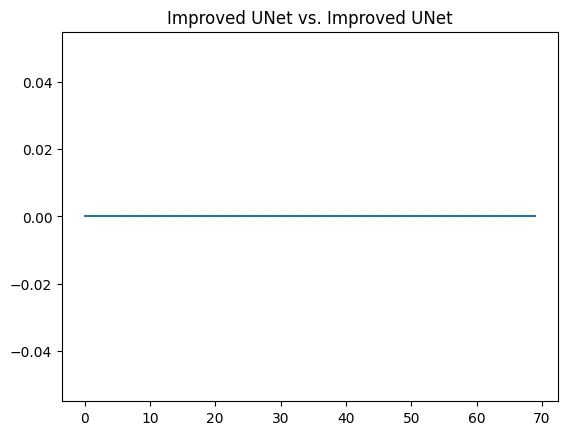

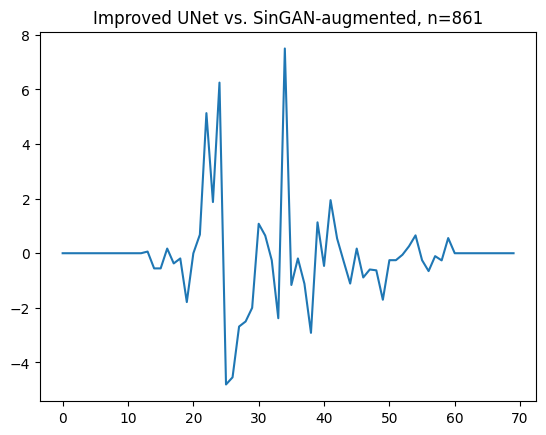

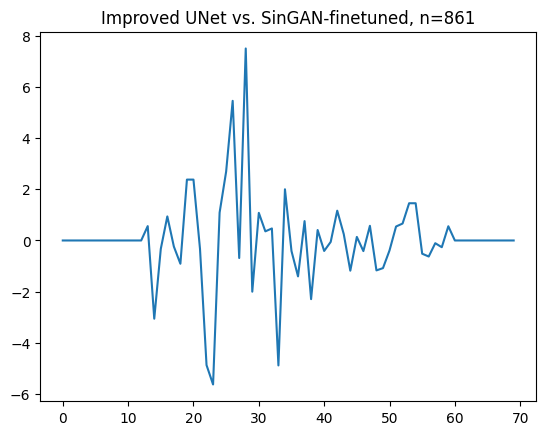

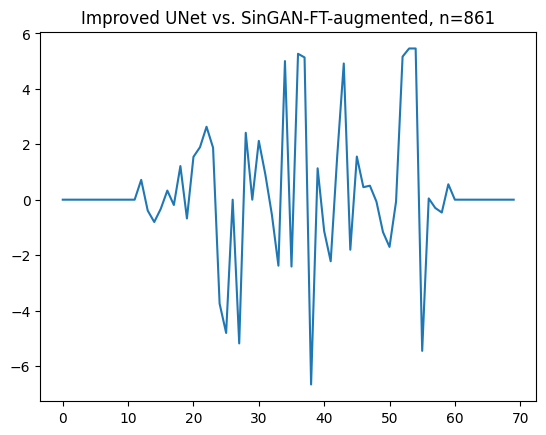

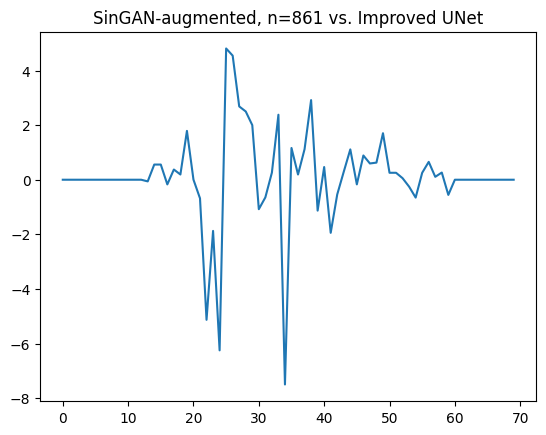

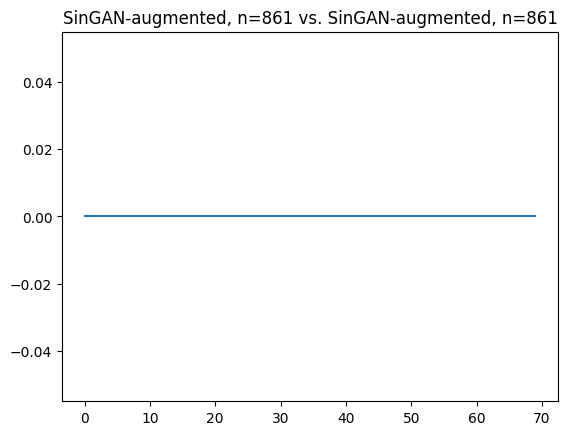

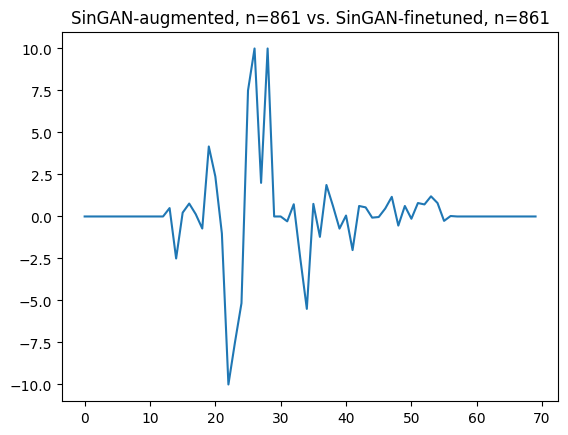

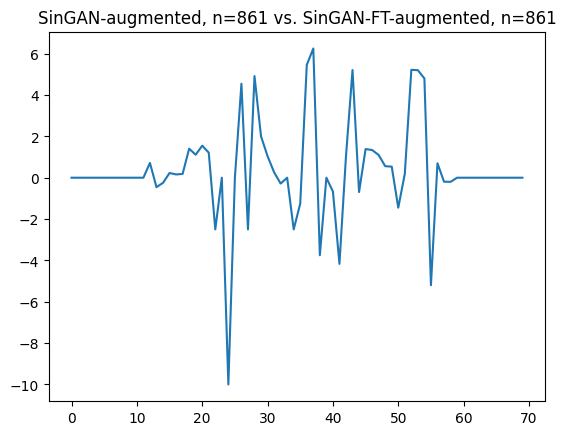

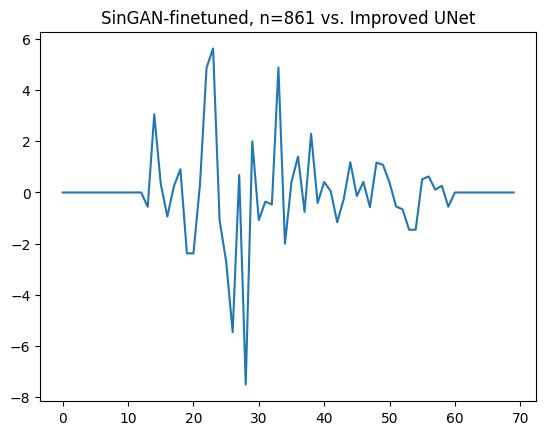

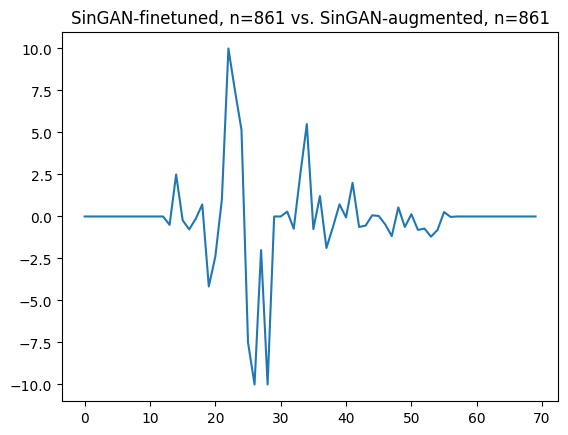

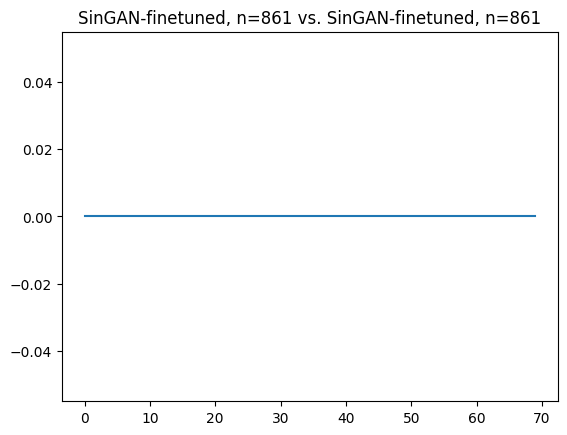

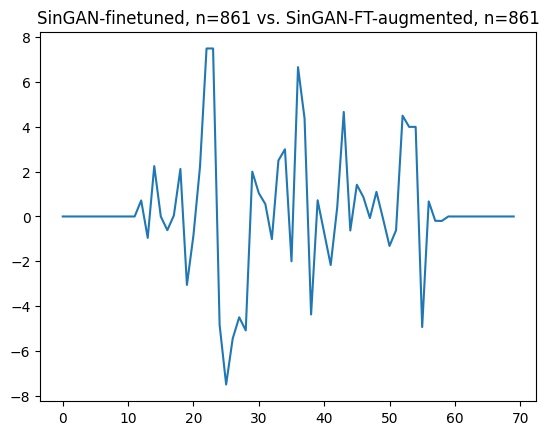

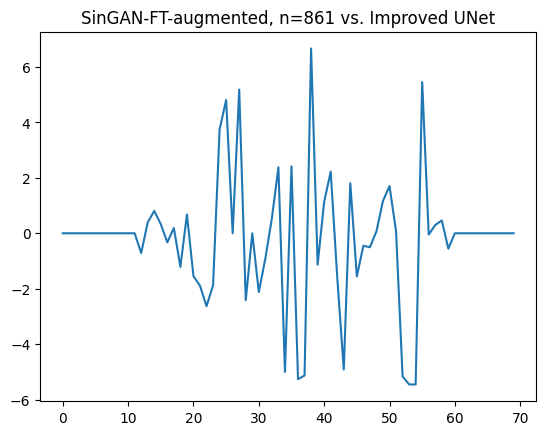

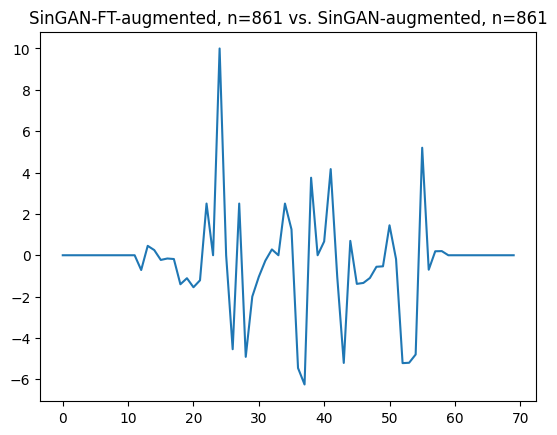

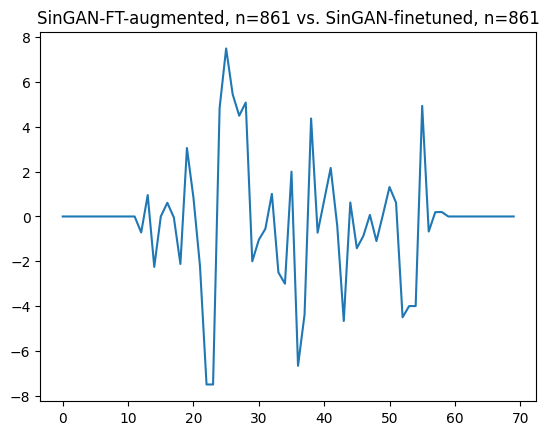

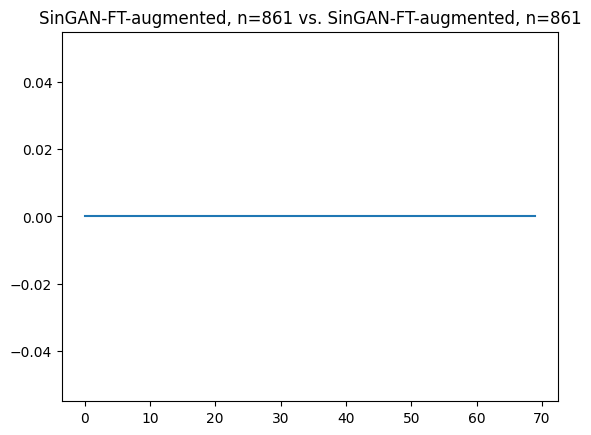

====
Subject: FD_032


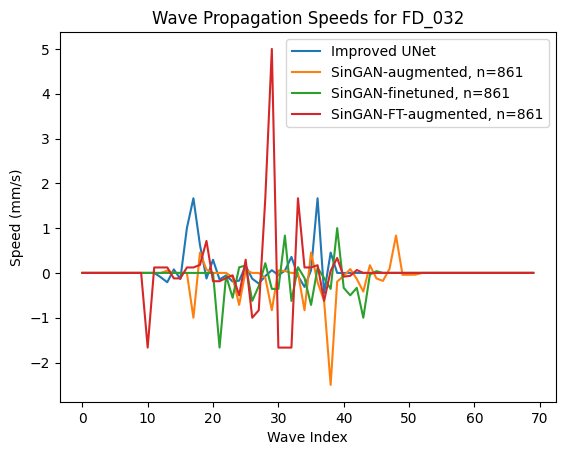

/tmp/ipykernel_2470025/568984630.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plt.imshow(t_test_p_values.fillna(1).values, vmin=-1, vmax=1, cmap='RdBu')


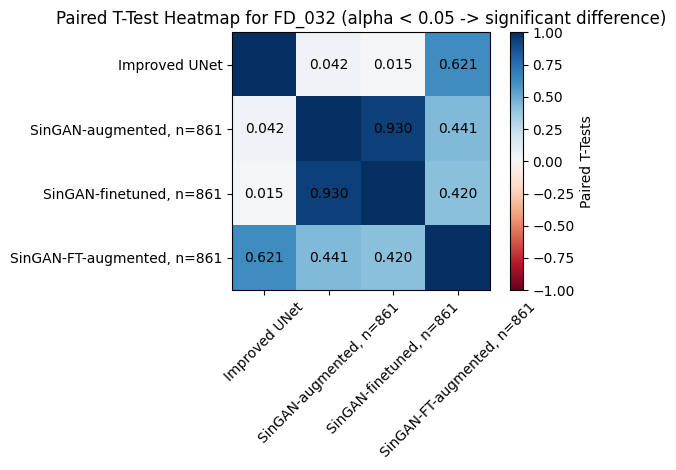

Pairs:
====


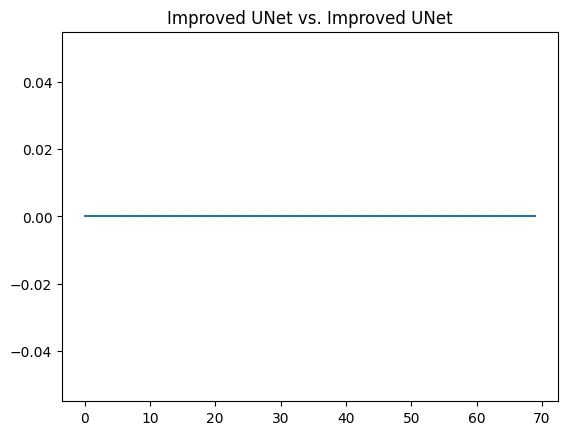

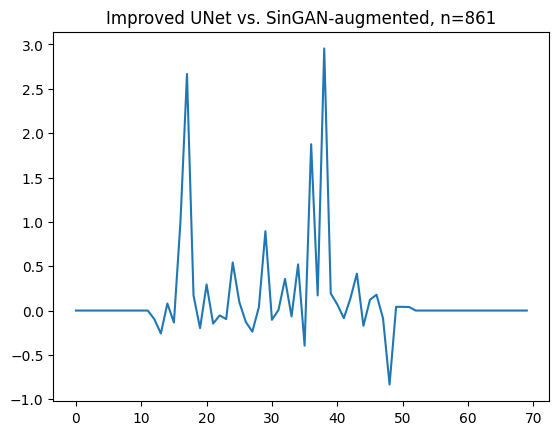

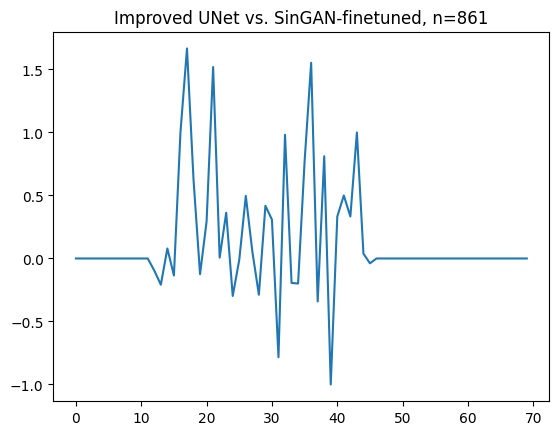

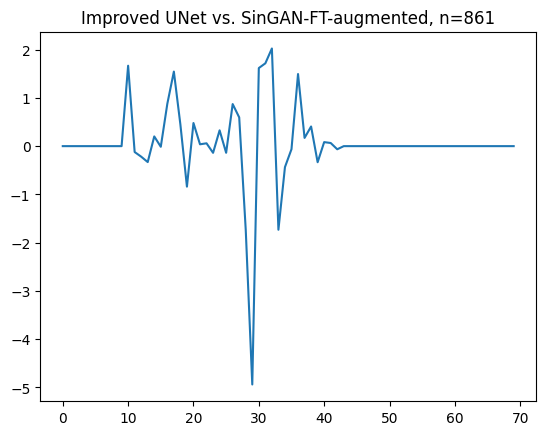

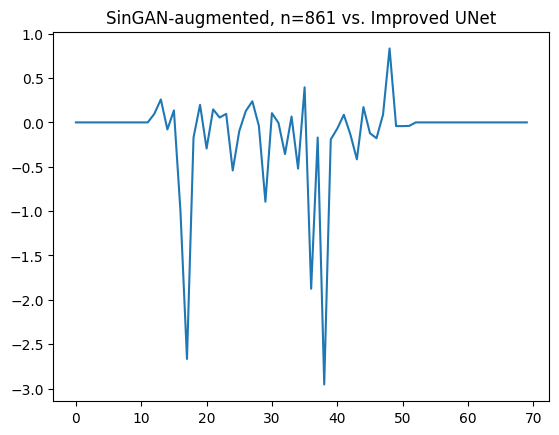

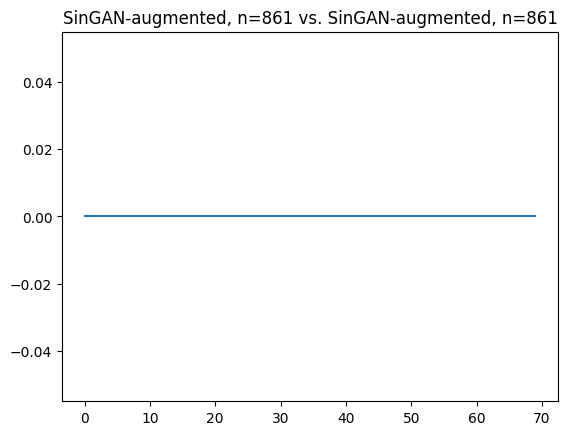

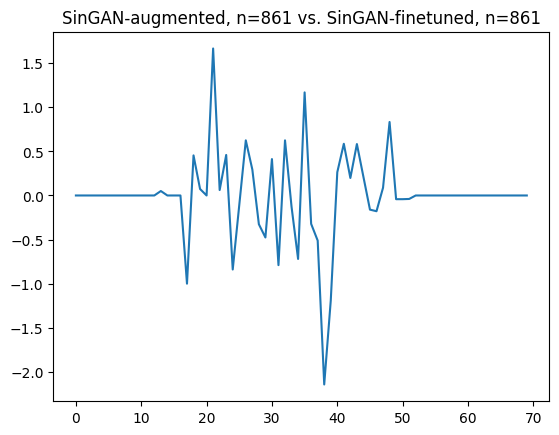

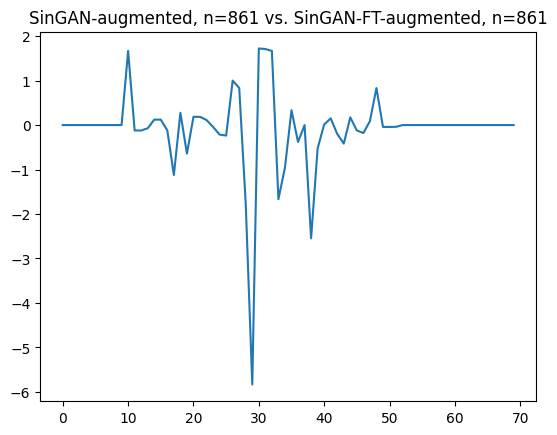

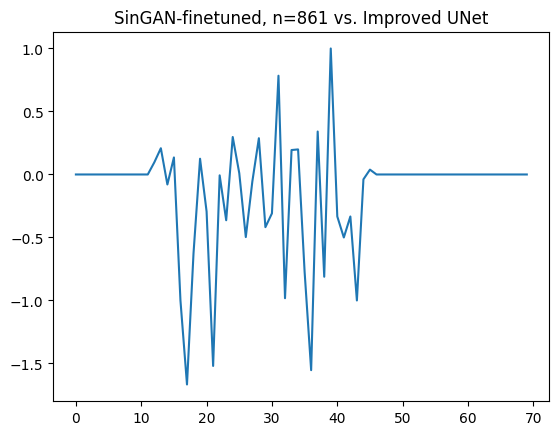

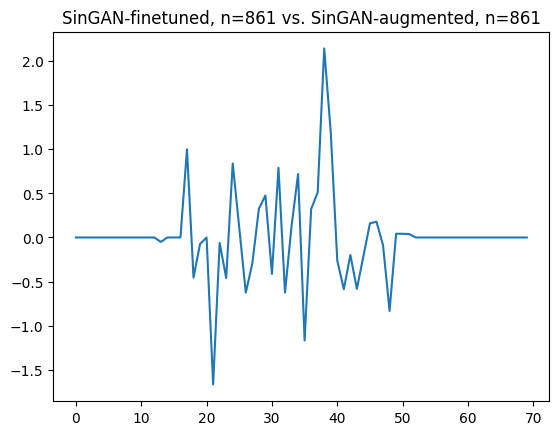

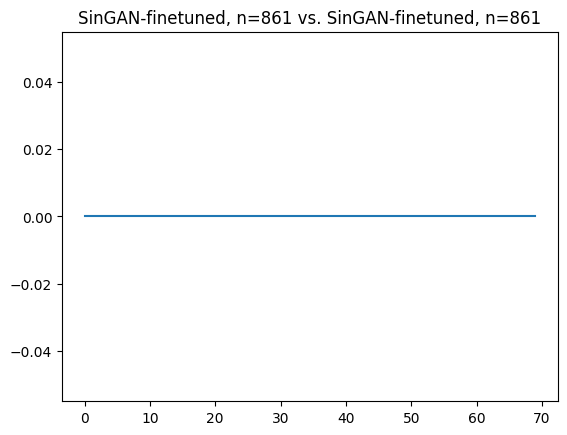

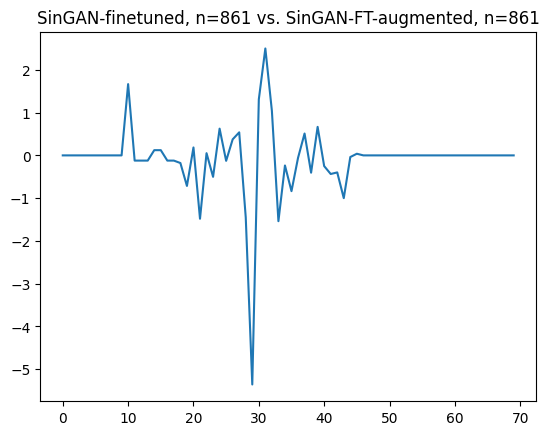

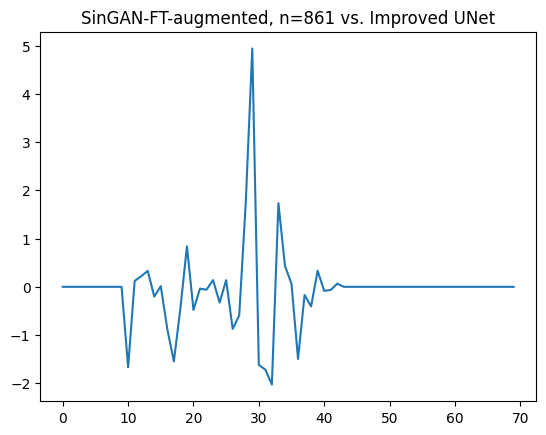

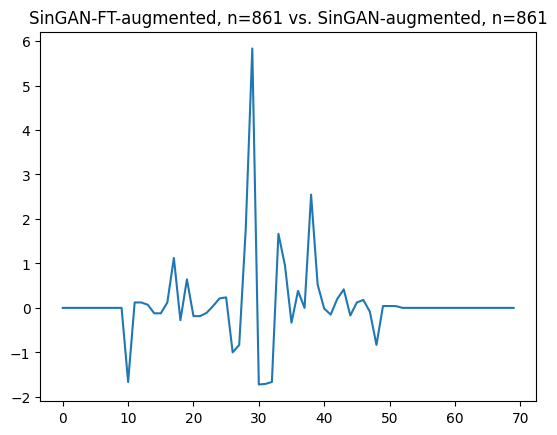

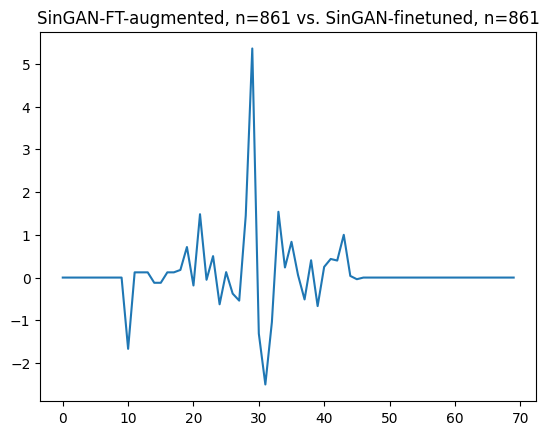

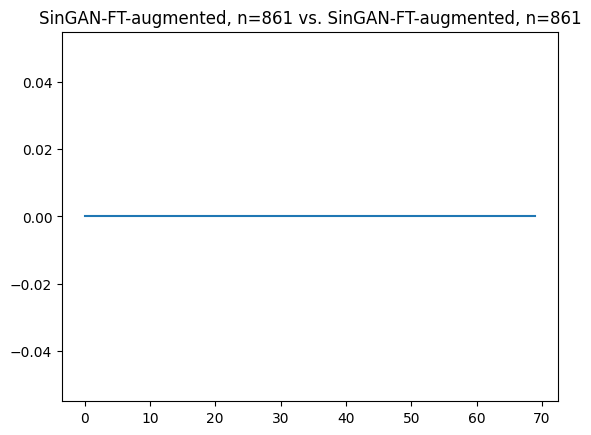

====


In [48]:
for subj, entries in results.items():
    print(f"Subject: {subj}")
    for entry in entries:
        # print(f"  Model: {entry['model']}")
        # print(f"  Stomach Mask Size: {entry['stomach_mask_size']}")
        # print(f"  Dominant Frequency (Hz): {entry['dominant_frequency_hz']}")
        # print(f"  Wave Propagation Speeds (mm/s): {entry['wave_propagation_speeds_mm_s']}")
        plt.plot(
            entry['wave_propagation_speeds_mm_s'],
            label=model_shortnames[entry['model']]
        )
        plt.xlabel('Wave Index')
        plt.ylabel('Speed (mm/s)')
        plt.title(f'Wave Propagation Speeds for {subj}')
        plt.legend()

    plt.show()

    models = [model_shortnames[entry['model']] for entry in entries]

    ts_data = {
        model_shortnames[entry['model']]: entry['wave_propagation_speeds_mm_s']
        for entry in entries
    }

    t_test_p_values = pd.DataFrame(columns=models, index=models)

    for model1 in models:
        for model2 in models:
            t_stat, p_t = ttest_rel(ts_data[model1], ts_data[model2]) 
            t_test_p_values.loc[model1, model2] = p_t if p_t else 0
    
    # Plot heatmap using matplotlib
    plt.figure()
    plt.imshow(t_test_p_values.fillna(1).values, vmin=-1, vmax=1, cmap='RdBu')
    for i in range(len(t_test_p_values.index)):
        for j in range(len(t_test_p_values.columns)):
            value = t_test_p_values.iloc[i, j]
            if pd.notna(value):
                plt.text(j, i, f"{float(value):.3f}", 
                        ha='center', va='center', color='black')
    plt.colorbar(label='Paired T-Tests')
    plt.xticks(range(len(t_test_p_values)), t_test_p_values.columns, rotation=45)
    plt.yticks(range(len(t_test_p_values)), t_test_p_values.index)
    plt.title(f'Paired T-Test Heatmap for {subj} (alpha < 0.05 -> significant difference)')
    plt.tight_layout()
    plt.show()

    print('Pairs:')
    print('====')

    for model1 in models:
        for model2 in models:
            plt.title(f'{model1} vs. {model2}')
            plt.plot(np.array(ts_data[model1]) - np.array(ts_data[model2]))
            plt.show()
    print('====')

In [42]:
t_test_p_values.fillna(1).values

/tmp/ipykernel_2470025/426760303.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  t_test_p_values.fillna(1).values


array([[1.        , 0.58818098, 0.88102213, 0.37420622],
       [0.58818098, 1.        , 0.67093069, 0.69560612],
       [0.88102213, 0.67093069, 1.        , 0.5355823 ],
       [0.37420622, 0.69560612, 0.5355823 , 1.        ]])

In [38]:
t_test_p_values

,Improved UNet,"SinGAN-augmented, n=861","SinGAN-finetuned, n=861","SinGAN-FT-augmented, n=861"
Improved UNet,NaN,0.588181,0.881022,0.374206
"SinGAN-augmented, n=861",0.588181,NaN,0.670931,0.695606
"SinGAN-finetuned, n=861",0.881022,0.670931,NaN,0.535582
"SinGAN-FT-augmented, n=861",0.374206,0.695606,0.535582,NaN


[{'model': 'uwm-unet-singan-train-set-size-861',
  'stomach_mask_size': (256, 256, 71, 132),
  'dominant_frequency_hz': 0.0909,
  'wave_propagation_speeds_mm_s': [-0.0382,
   -0.0382,
   -0.0382,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   inf,
   -0.0382,
   -0.0382,
   -0.0382,
   -0.0382,
   -0.0382,
   -0.0382,
   -0.0382]},
 {'model': 'uwm-unet-singan-finetuning-train-set-size-861',
  'stomach_mask_size': (256, 256, 71, 132),
  'dominant_frequency_hz': 0.053,
  'wave_propagation_speeds_mm_s': [-0.0382,
   -0.0382,
   -0.0382,
   -0.0382,
   -0.0382,
   -0.03

Model: uwm-unet-singan-train-set-size-861, CV Subject: FD_027
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0909

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382       Inf       Inf       Inf       Inf

  Columns 8 through 14

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 15 through 21

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 22 through 28

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 43 through 49

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 50 through 56

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 57 through 63

       Inf       Inf    

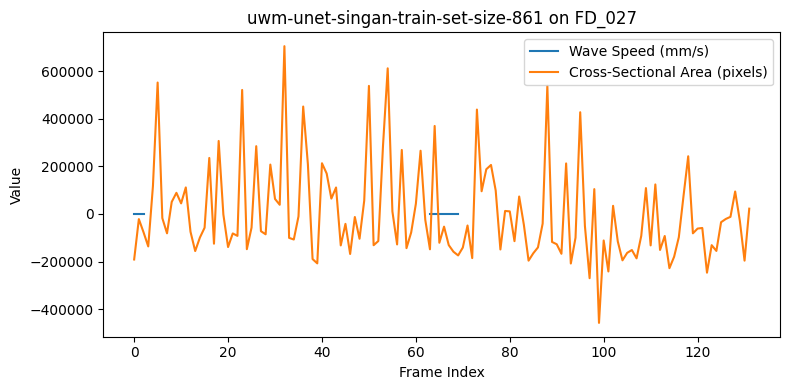

Model: uwm-unet-singan-finetuning-train-set-size-861, CV Subject: FD_027
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0530

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 15 through 21

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 22 through 28

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 43 through 49

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 50 through 56

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 57 through 63

       Inf   

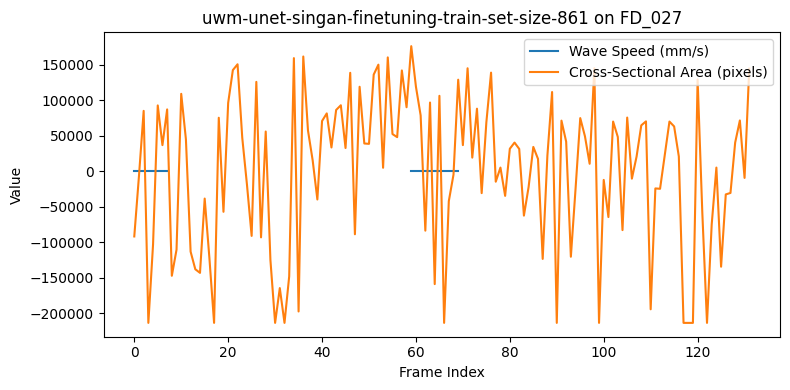

Model: uwm-unet-singan-finetuned-n-10-10x-train-set-size-861, CV Subject: FD_027
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0606

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382       Inf       Inf       Inf

  Columns 8 through 14

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 15 through 21

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 22 through 28

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 43 through 49

       Inf       Inf       Inf       Inf       Inf       Inf    0.1562

  Columns 50 through 56

       Inf   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 57 through 63

   -0

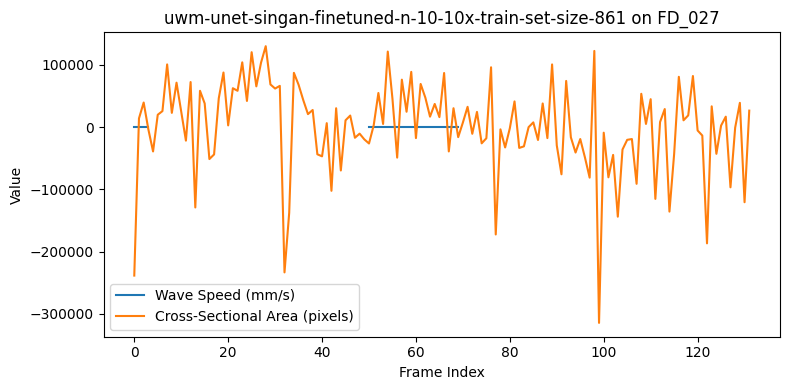

Model: uwm-unet-train-set-size-288, CV Subject: FD_027
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
     0

Lags:
  Columns 1 through 13

   -10    -9    -8    -7    -6    -5    -4    -3    -2    -1     0     1     2

  Columns 14 through 21

     3     4     5     6     7     8     9    10

Lags:
  Columns 1 through 13

   -10    -9    -8    -7    -6    -5    -4    -3    -2    -1     0     1     2

  Columns 14 through 21

     3     4     5     6     7     8     9    10

Lags:
  Columns 1 through 13

   -10    -9    -8    -7    -6    -5    -4    -3    -2    -1     0     1     2

  Columns 14 through 21

     3     4     5     6     7     8     9    10

Lags:
  Columns 1 through 13

   -10    -9    -8    -7    -6    -5    -4    -3    -2    -1     0     1     2

  Columns 14 through 21

     3     4     5     6     7     8     9    10

Lags:
  Columns 1 through 13

   -10    -9    -8    -7    -6    -5    -4    -3    -2    -1     0     1     2

  Columns 14 th

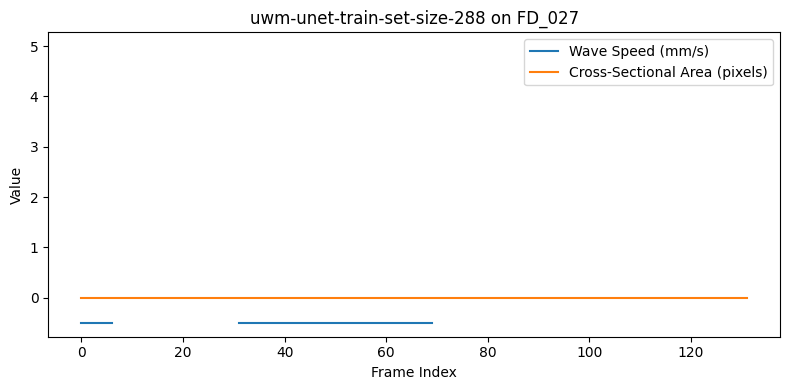

Model: uwm-unet-singan-train-set-size-861, CV Subject: FD_031
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0985

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 15 through 21

   -0.0382   -0.0382       Inf       Inf       Inf       Inf       Inf

  Columns 22 through 28

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 43 through 49

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 50 through 56

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 57 through 63

    0.2000   -0.0382   -

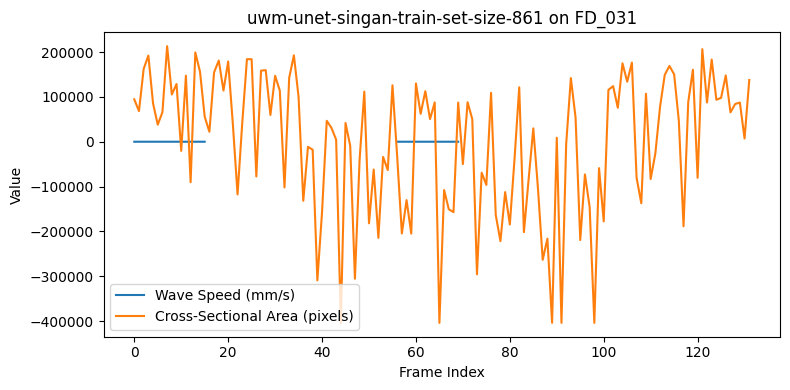

Model: uwm-unet-singan-finetuning-train-set-size-861, CV Subject: FD_031
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0985

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382       Inf

  Columns 15 through 21

       Inf       Inf       Inf   -0.2174       Inf       Inf       Inf

  Columns 22 through 28

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 43 through 49

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 50 through 56

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 57 through 63

    0.1724   

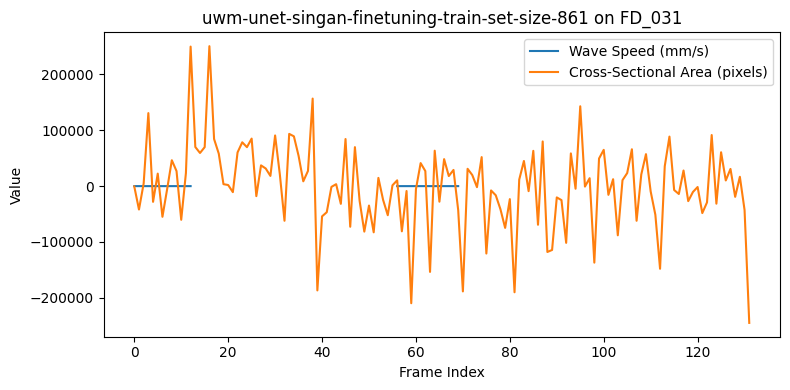

Model: uwm-unet-singan-finetuned-n-10-10x-train-set-size-861, CV Subject: FD_031
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0985

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.7143       Inf

  Columns 15 through 21

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 22 through 28

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 43 through 49

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 50 through 56

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 57 through 63

     

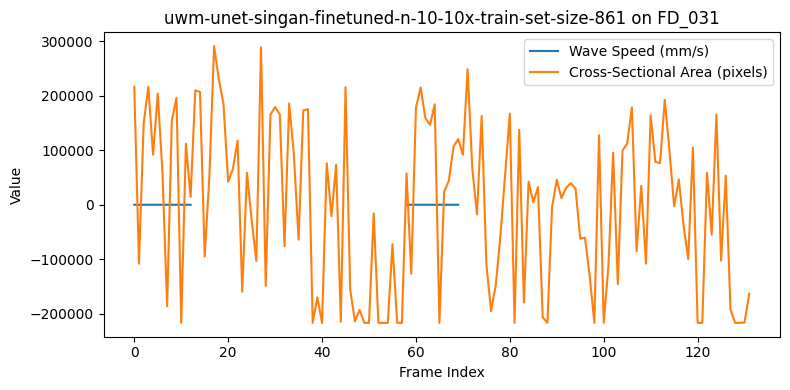

Model: uwm-unet-singan-train-set-size-861, CV Subject: FD_029
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0909

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 15 through 21

   -0.0382   -0.0382   -0.0382   -0.0382       Inf       Inf       Inf

  Columns 22 through 28

       Inf       Inf       Inf   -5.0000       Inf       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 43 through 49

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 50 through 56

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 57 through 63

       Inf       Inf    

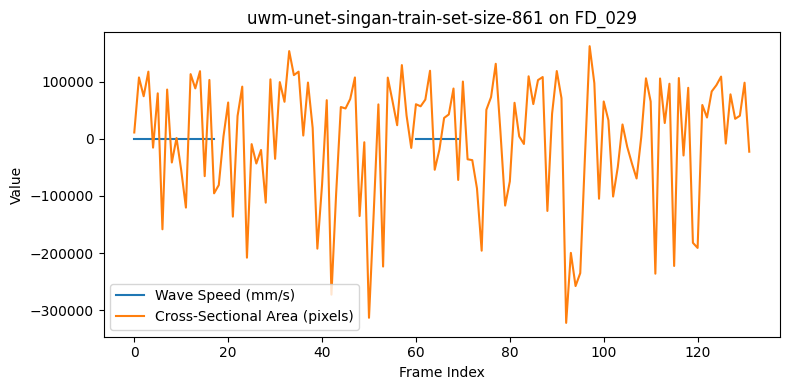

Model: uwm-unet-singan-finetuning-train-set-size-861, CV Subject: FD_029
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0682

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 15 through 21

   -0.0382   -0.0382   -0.0382   -0.0382       Inf       Inf       Inf

  Columns 22 through 28

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 43 through 49

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 50 through 56

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 57 through 63

       Inf   

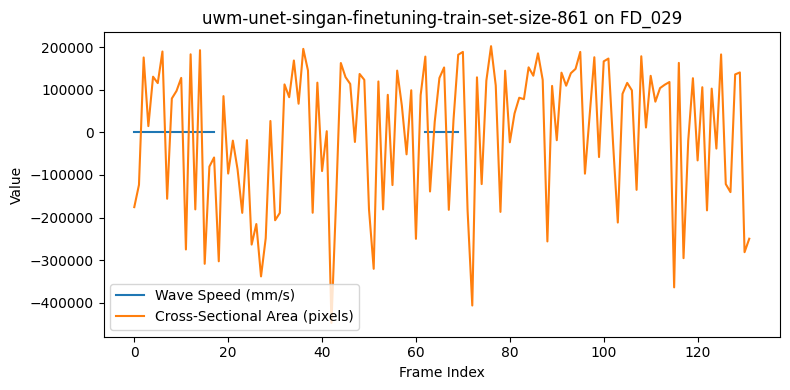

Model: uwm-unet-singan-finetuned-n-10-10x-train-set-size-861, CV Subject: FD_029
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0606

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 15 through 21

   -0.0382   -0.0382   -0.0382   -0.0382       Inf       Inf       Inf

  Columns 22 through 28

   -0.1724       Inf    0.3571       Inf    2.5000       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 43 through 49

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 50 through 56

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 57 through 63

     

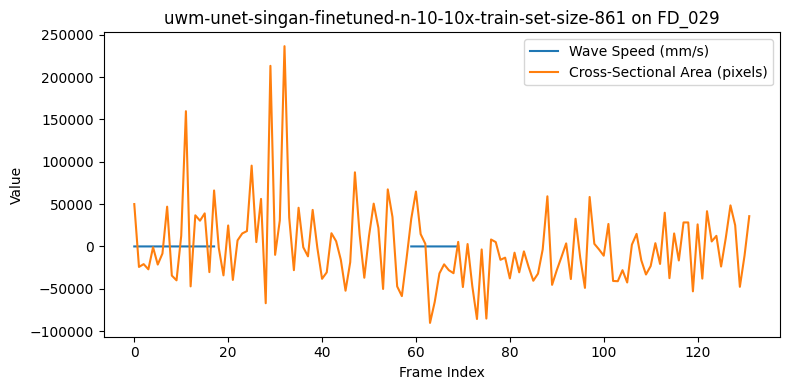

Model: uwm-unet-singan-train-set-size-861, CV Subject: FD_032
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.1818

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382       Inf

  Columns 15 through 21

   -0.0382   -0.0382   -0.0382   -1.0000       Inf       Inf   -0.0382

  Columns 22 through 28

   -0.0382   -0.0382   -0.0962   -0.7143    0.0581   -0.0382   -0.0382

  Columns 29 through 35

   -0.1087       Inf       Inf    0.0435   -0.0382   -0.0382       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf   -0.0694    0.0862

  Columns 43 through 49

       Inf       Inf    0.1724   -0.1220       Inf    0.0877    0.8333

  Columns 50 through 56

       Inf       Inf       Inf   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 57 through 63

   -0.0382   -0.0382   -

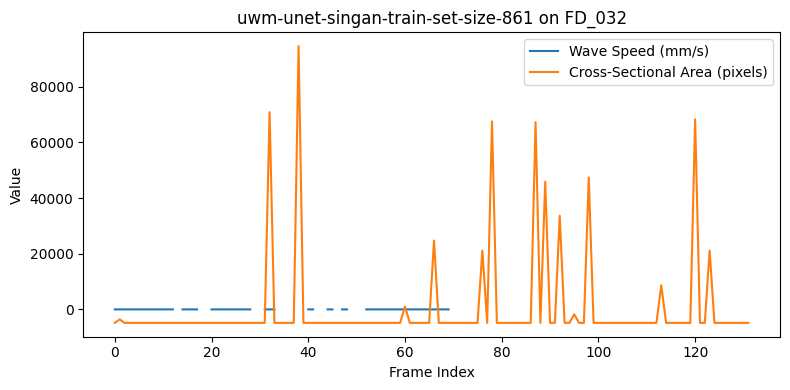

Model: uwm-unet-singan-finetuning-train-set-size-861, CV Subject: FD_032
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.1970

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 15 through 21

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 22 through 28

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 43 through 49

   -0.3333       Inf       Inf       Inf   -0.0382   -0.0382   -0.0382

  Columns 50 through 56

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 57 through 63

   -0.0382   

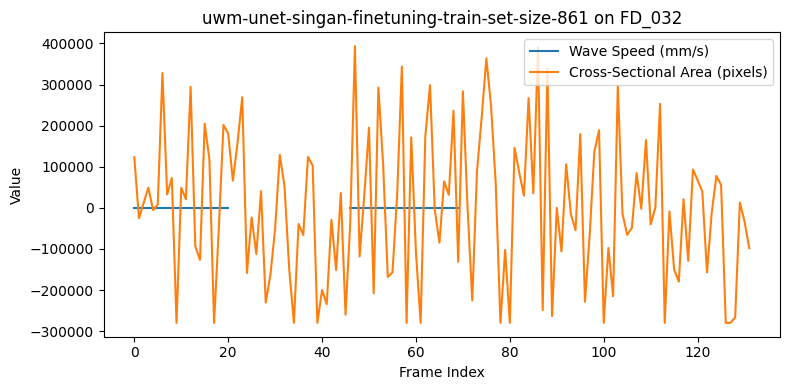

Model: uwm-unet-singan-finetuned-n-10-10x-train-set-size-861, CV Subject: FD_032
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.1894

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382   -0.0382   -0.0382       Inf       Inf       Inf       Inf

  Columns 15 through 21

       Inf       Inf       Inf       Inf       Inf    0.7143       Inf

  Columns 22 through 28

   -0.1852   -0.1136       Inf       Inf       Inf       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf    0.3333   -0.0833       Inf

  Columns 43 through 49

       Inf   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 50 through 56

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 57 through 63

   -0

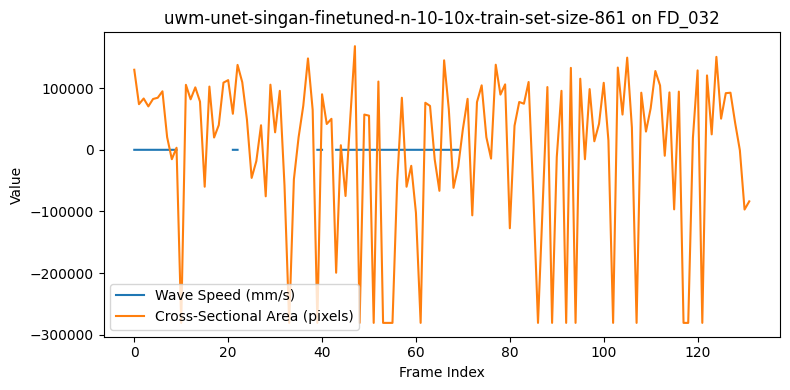

Model: uwm-unet-singan-train-set-size-861, CV Subject: FD_030
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0985

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 15 through 21

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 22 through 28

   -0.0382   -0.0382    0.1163       Inf       Inf       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 43 through 49

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 50 through 56

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 57 through 63

       Inf       Inf    

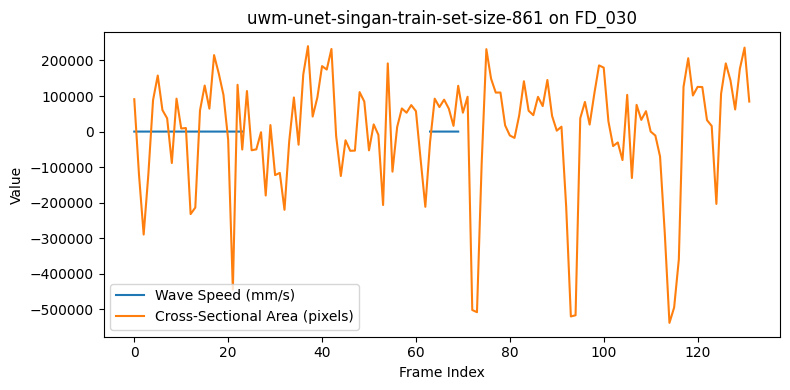

Model: uwm-unet-singan-finetuning-train-set-size-861, CV Subject: FD_030
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0530

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 15 through 21

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 22 through 28

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 29 through 35

   -0.0382   -0.0382   -0.0382   -0.0382    0.1471       Inf       Inf

  Columns 36 through 42

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 43 through 49

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 50 through 56

       Inf       Inf   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 57 through 63

   -0.0382   

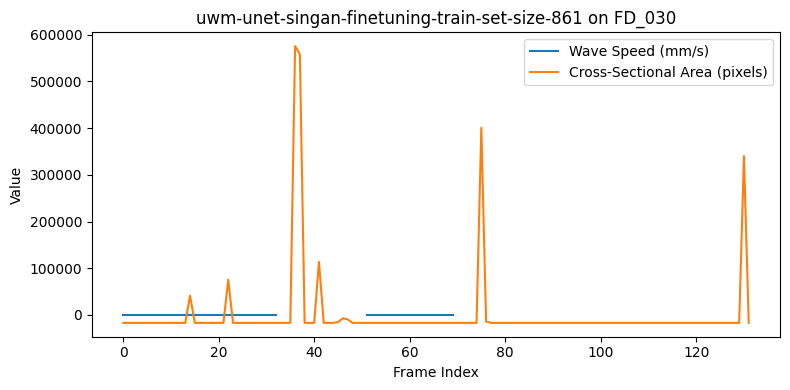

Model: uwm-unet-singan-finetuned-n-10-10x-train-set-size-861, CV Subject: FD_030
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0985

Wave propagation speeds (mm/s):
  Columns 1 through 7

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 8 through 14

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 15 through 21

   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382   -0.0382

  Columns 22 through 28

   -0.0382   -0.0382   -0.0382   -0.0382       Inf       Inf       Inf

  Columns 29 through 35

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 36 through 42

       Inf       Inf    0.3846    5.0000       Inf       Inf       Inf

  Columns 43 through 49

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 50 through 56

       Inf       Inf       Inf       Inf       Inf       Inf       Inf

  Columns 57 through 63

     

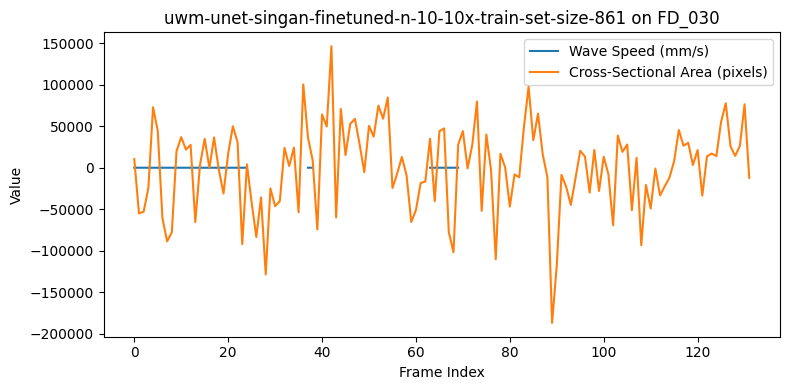

In [32]:
for cv_subject in cv_subjects:
    for model_data in output_data:
        if model_data['cv_subject'] != cv_subject:
            continue
        total_area = model_data['cross_section_data']
        print(f"Model: {model_data['model']}, CV Subject: {cv_subject}")
        print(model_data['matlab_output'])
        selected_model = [res for res in results[cv_subject] if res['model'] == model_data['model']][0]


        wave_speeds = selected_model['wave_propagation_speeds_mm_s']

        plt.figure(figsize=(8,4))
        plt.plot(wave_speeds, label='Wave Speed (mm/s)')
        plt.plot(total_area,  label='Cross‐Sectional Area (pixels)')
        plt.xlabel('Frame Index')
        plt.ylabel('Value')
        plt.title(f"{model_data['model']} on {cv_subject}")
        plt.legend()
        plt.tight_layout()
        plt.show()


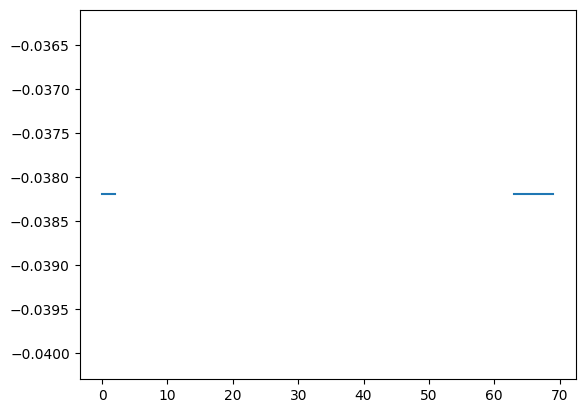